# importing packages

In [1]:

import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.cm as cm
import random
import warnings
import pandas as pd
import copy
import pickle

from sklearn.datasets import load_digits
from pprint import pprint
from minisom import MiniSom
from matplotlib.collections import PatchCollection
from sklearn.preprocessing import scale
from mpl_toolkits.mplot3d import Axes3D

warnings.filterwarnings("ignore")


# Task 1: Clustering using SOM

**Preparing Dataset italicized text**

In [ ]:
""""
	see the properties of digits and print its description
		to see the attributes and shape of each of which,
		uncomment the section bellow
"""
digits = load_digits()
#pprint(digits)
#print(digits.DESCR)
#print(digits.data.shape)
#print(digits.images.shape)
#print(digits.target.shape)


raw_data = scale(digits.data)
raw_label = digits.target
raw_images = digits.images;

"""
		Shuffle and Split Data to two categories, Train Data and Test Data with
		ratio of 80%
"""
combined_data = list(zip(raw_data, raw_label, raw_images))
random.shuffle(combined_data)
shuffled_data, shuffled_label, shuffled_image = zip(*combined_data)


all_data = shuffled_data
all_label = shuffled_label
all_images = shuffled_image


**Creating and Initializing SOM models**

In [ ]:
som_4X4   = MiniSom(4,  4,  64, sigma=3, learning_rate=0.5, neighborhood_function='triangle')
som_20X20 = MiniSom(20, 20, 64, sigma=4, learning_rate=0.5, neighborhood_function='triangle')

**Training Networks**

In [ ]:
#trainning SOM Models on All Data
som_4X4.train  (all_data, 10000, verbose=True)
som_20X20.train(all_data, 10000, verbose=True)

 [ 10000 / 10000 ] 100% - 0:00:00 left 
 quantization error: 5.652592270269983
 [ 10000 / 10000 ] 100% - 0:00:00 left 
 quantization error: 3.544862835810887


**Visualization**

  

4X4 Model

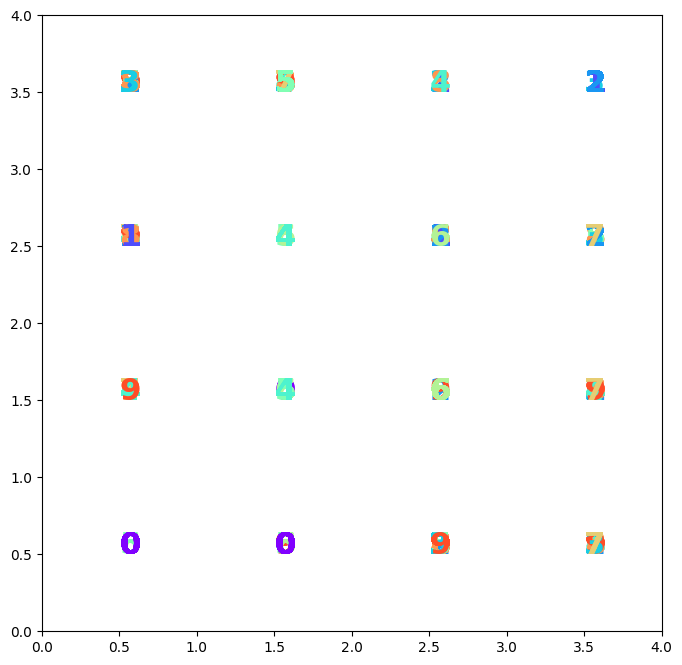

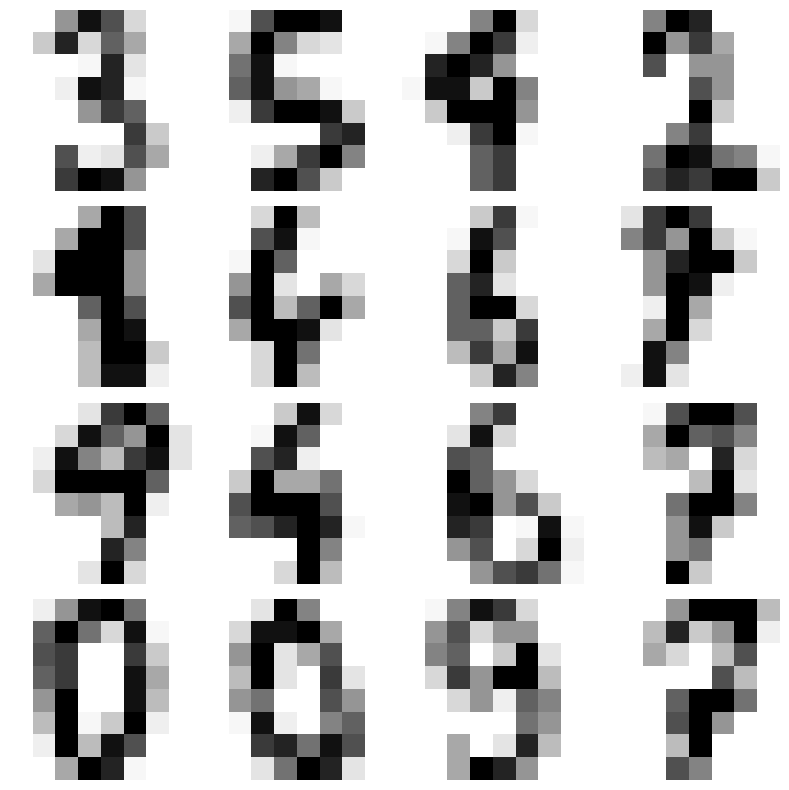


The hit map matrix for 4X4 model:
(flipped horizontally): 
[[ 61 161 106  78]
 [263 148 165   5]
 [144  98  54 152]
 [ 49  19 113 181]]



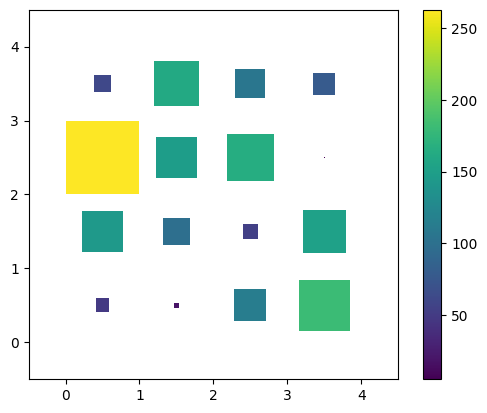


Dead Neurons:
	There is no dead neuron in 4X4 SOM model.


In [ ]:
plt.figure(figsize=(8, 8))
wmap_4X4 = {}
hcntr4 = np.zeros((4,4,), dtype=int);
im = 0
for x, t in zip(all_data, all_label):  # scatterplot
    w = som_4X4.winner(x)
    wmap_4X4[w] = im
    hcntr4[w] = hcntr4[w]+1
    plt. text(w[0]+0.5,  w[1]+0.5,  str(t),
              color=plt.cm.rainbow(t / 10.), fontdict={'weight': 'bold',  'size': 22})
    im = im + 1
plt.axis([0, som_4X4.get_weights().shape[0], 0,  som_4X4.get_weights().shape[1]])
plt.savefig('outputs/figures/SOM_4X4_clustering_map.png')
plt.show()
print("")

plt.figure(figsize=(8, 8), facecolor='white')
cnt = 0
for j in reversed(range(4)):  # images mosaic
    for i in range(4):
        plt.subplot(4, 4, cnt+1, frameon=False,  xticks=[],  yticks=[])
        if (i, j) in wmap_4X4:
            plt.imshow(all_images[wmap_4X4[(i, j)]],
                       cmap='Greys', interpolation='nearest')
        else:
            plt.imshow(np.zeros((8, 8)),  cmap='Greys')
        cnt = cnt + 1

plt.tight_layout()
plt.savefig('outputs/figures/SOM_4X4_data.png')
plt.show()
print("")


#
# Hit Map
#
print("The hit map matrix for 4X4 model:\r\n(flipped horizontally): ")
print(np.flipud(hcntr4))
print("")
nhcntr4 = hcntr4 / hcntr4.max()
fig = plt.figure()
ax = fig.add_subplot(111, aspect='equal')
all_patches = []
cmap = cm.get_cmap('viridis')
for i in range(4):
    for j in range(4):
        edge = nhcntr4[j][i];
        rect_color = cmap(nhcntr4[j][i])
        all_patches.append(patches.Rectangle((i+0.5-edge/2, j+0.5-edge/2), edge, edge, linewidth=1, fill=1, facecolor=rect_color,))
ax.add_collection(PatchCollection(all_patches))
pc = PatchCollection(all_patches, cmap=cmap)  # Set cmap here
pc.set_array(np.transpose(nhcntr4).flatten())  # Set array for color mapping
ax.add_collection(pc)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=hcntr4.min(), vmax=hcntr4.max()))
sm.set_array(np.transpose(nhcntr4).flatten())  # Set array for color bar
plt.colorbar(sm, ax=ax)
plt.axis([-0.5, som_4X4.get_weights().shape[0]+0.5, -0.5,  som_4X4.get_weights().shape[1]+0.5])
plt.savefig('outputs/figures/SOM_4X4_Hit_map.png')
plt.show()
print("")

#
#   Dead Neurons
#
print("Dead Neurons:")
dead_cntr = 0
for i in range(4):
    for j in range(4):
        if hcntr4[i,j] == 0:
            print("\tNeuron (", i, ", ", j, ") is dead.")
            dead_cntr += 1
if dead_cntr == 0:
    print("\tThere is no dead neuron in 4X4 SOM model.")
else:
    print("\r\nThere are ", dead_cntr, " dead neurons in 4X4 SOM model.")

20X20 Model

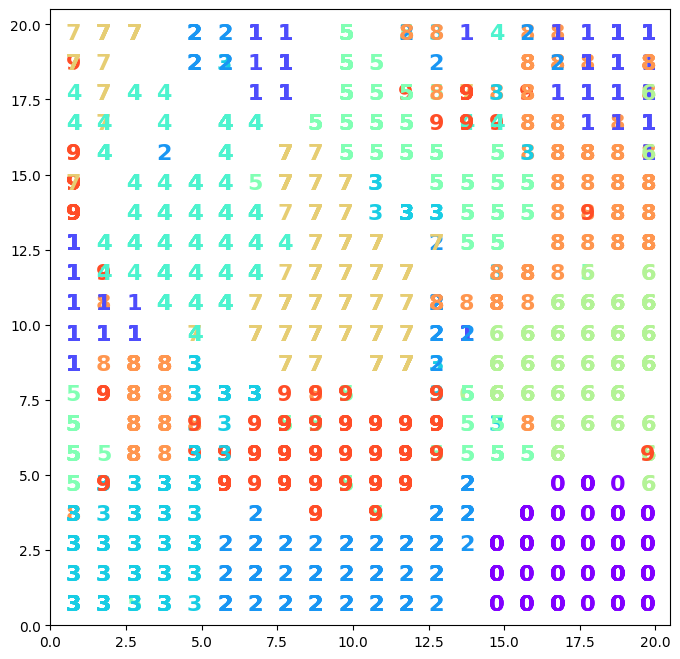

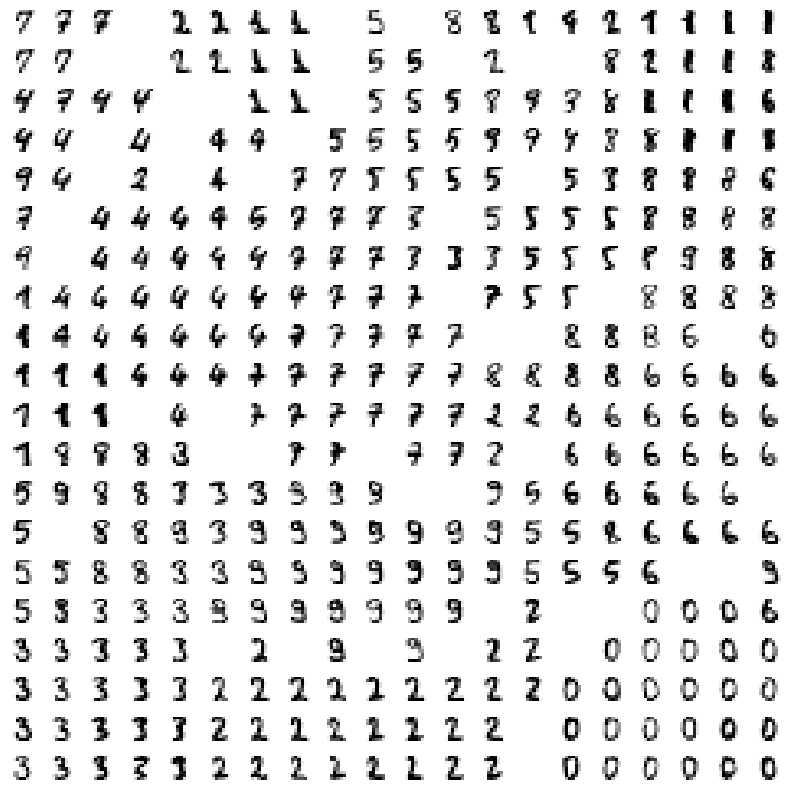


The hit map matrix for 20X20 model (flipped horizontally): 
[[ 7  9  8  6  2  5  3  0  9  6  8  2  7  5  6  7  9  9  5 10]
 [ 7 13  7  7  1  0  4  6  8 11  5  0  4  5  4  3  7  5  8 16]
 [ 3  5  6  3  7  0  4  4  4  5  6  2  2  2  2  7  3  6 14  3]
 [11  6  8  7  2  9  8  6  7  9  5  1  3  2  3  5  6  2  4  5]
 [ 7  4 13  9  0  3  2  5  6  6  1  6  0  3  5  2  4  3  6  2]
 [ 4  8 10  0  0  9  3 14  8  2  8  3  5  6  3  4  4  2  0  1]
 [ 0  0  1  6  9  2  2  4  0  6  1  0  3  4  4  0  5  7  0  1]
 [ 2  6  8  8  0  7  6  4  3  4  8  0  3  4  4  8  1  2  1  2]
 [ 8  3  8  0  6  9  4  0 11  3  2  5  0 10  0  6  5  9  0  5]
 [ 5  7  5  6  6  4  5  0  6  5  3  6  8  1  2  5  7  3  2  0]
 [ 5  4  6  0  7  3  4  4  0  5  6  4  8  3  4  5  5  9 10 10]
 [ 6  6  2  3  4  5 12  3  3  7  4  6  3  6  3  2  5  0  0  0]
 [ 6  3  4  0  7  7  9  1  3  3  8  1  2  1  9  9  0  6  9  2]
 [ 3  8  5  2  2  5  2 10  0  5  2  7  6  8  1  0  4  3  1  6]
 [ 6  3  2  0  9  5  1  8  0  0 10  5  6  9  3  6 12  0  

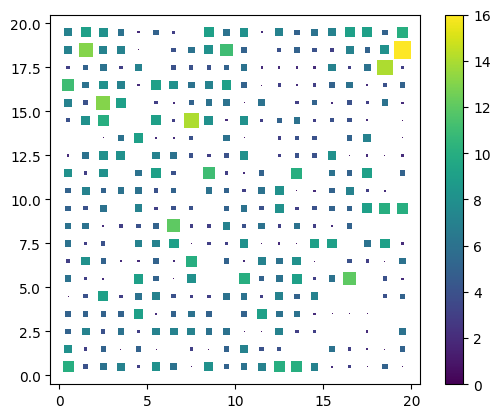


Dead Neurons:
	Neuron ( 1 ,  6 ) is dead.
	Neuron ( 1 ,  13 ) is dead.
	Neuron ( 1 ,  14 ) is dead.
	Neuron ( 2 ,  15 ) is dead.
	Neuron ( 2 ,  16 ) is dead.
	Neuron ( 2 ,  18 ) is dead.
	Neuron ( 3 ,  9 ) is dead.
	Neuron ( 3 ,  18 ) is dead.
	Neuron ( 3 ,  19 ) is dead.
	Neuron ( 4 ,  15 ) is dead.
	Neuron ( 4 ,  16 ) is dead.
	Neuron ( 4 ,  17 ) is dead.
	Neuron ( 5 ,  3 ) is dead.
	Neuron ( 5 ,  8 ) is dead.
	Neuron ( 5 ,  9 ) is dead.
	Neuron ( 5 ,  17 ) is dead.
	Neuron ( 6 ,  8 ) is dead.
	Neuron ( 6 ,  15 ) is dead.
	Neuron ( 7 ,  3 ) is dead.
	Neuron ( 7 ,  16 ) is dead.
	Neuron ( 8 ,  17 ) is dead.
	Neuron ( 8 ,  18 ) is dead.
	Neuron ( 8 ,  19 ) is dead.
	Neuron ( 9 ,  3 ) is dead.
	Neuron ( 9 ,  8 ) is dead.
	Neuron ( 10 ,  7 ) is dead.
	Neuron ( 10 ,  19 ) is dead.
	Neuron ( 11 ,  3 ) is dead.
	Neuron ( 11 ,  7 ) is dead.
	Neuron ( 11 ,  12 ) is dead.
	Neuron ( 11 ,  14 ) is dead.
	Neuron ( 11 ,  18 ) is dead.
	Neuron ( 12 ,  4 ) is dead.
	Neuron ( 12 ,  11 ) is dead.
	Ne

In [ ]:
plt.figure(figsize=(8, 8))
wmap_20X20 = {}
hcntr20 = np.zeros((20,20,), dtype=int);
im = 0
for x, t in zip(all_data, all_label):  # scatterplot
    w = som_20X20.winner(x)
    wmap_20X20[w] = im
    hcntr20[w] = hcntr20[w]+1
    plt. text(w[0]+0.5,  w[1]+0.5,  str(t),
              color=plt.cm.rainbow(t / 10.), fontdict={'weight': 'bold',  'size': 16})
    im = im + 1
plt.axis([0, som_20X20.get_weights().shape[0]+0.5, 0,  som_20X20.get_weights().shape[1]+0.5])
plt.savefig('outputs/figures/SOM_20X20_clustering_map.png')
plt.show()
print("")

plt.figure(figsize=(8, 8), facecolor='white')
cnt = 0
for j in reversed(range(20)):  # images mosaic
    for i in range(20):
        plt.subplot(20, 20, cnt+1, frameon=False,  xticks=[],  yticks=[])
        if (i, j) in wmap_20X20:
            plt.imshow(all_images[wmap_20X20[(i, j)]],
                       cmap='Greys', interpolation='nearest')
        else:
            plt.imshow(np.zeros((8, 8)),  cmap='Greys')
        cnt = cnt + 1

plt.tight_layout()
plt.savefig('outputs/figures/SOM_20X20_data.png')
plt.show()
print("")


#
# Hit Map
#
print("The hit map matrix for 20X20 model (flipped horizontally): ")
print(np.flipud(hcntr20))
print("")
nhcntr20 = hcntr20 / hcntr20.max()
fig = plt.figure()
ax = fig.add_subplot(111, aspect='equal')
all_patches = []
cmap = cm.get_cmap('viridis')
for i in range(20):
    for j in range(20):
        edge = nhcntr20[j][i];
        rect_color = cmap(nhcntr20[j][i])
        all_patches.append(patches.Rectangle((i+0.5-edge/2, j+0.5-edge/2), edge, edge, linewidth=1, fill=1, facecolor=rect_color,))
ax.add_collection(PatchCollection(all_patches))
pc = PatchCollection(all_patches, cmap=cmap)  # Set cmap here
pc.set_array(np.transpose(nhcntr20).flatten())  # Set array for color mapping
ax.add_collection(pc)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=hcntr20.min(), vmax=hcntr20.max()))
sm.set_array(np.transpose(nhcntr20).flatten())  # Set array for color bar
plt.colorbar(sm, ax=ax)
plt.axis([-0.5, som_20X20.get_weights().shape[0]+0.5, -0.5,  som_20X20.get_weights().shape[1]+0.5])
plt.savefig('outputs/figures/SOM_20X20_Hit_map.png')
plt.show()
print()

#
#   Dead Neurons
#
print("Dead Neurons:")
dead_cntr = 0
for i in range(20):
    for j in range(20):
        if hcntr20[i,j] == 0:
            print("\tNeuron (", i, ", ", j, ") is dead.")
            dead_cntr += 1
if dead_cntr == 0:
    print("\tThere is no dead neuron in 20X20 SOM model.")
else:
    print("\r\nThere are ", dead_cntr, " dead neurons in 20X20 SOM model.")

**Calculating the Quantization Error**

In [ ]:
#
# 4X4
#
Wghts_4X4   = som_4X4.get_weights();
QE_acc = 0
for x in all_data:
    # calculate the distance between the data and each neurons and find the nearest
    sumi = np.zeros((4,4,))
    for i in range(4):
        for j in range(4):
            sumi[i,j] = np.sqrt( np.sum( np.square(Wghts_4X4[i,j] - x) ) )
    QE_acc += sumi.min();
print("The Quantization error of 4X4   neuron SOM model is: ", QE_acc/len(all_data))


#
# 20X20
#
Wghts_20X20   = som_20X20.get_weights();
QE_acc = 0
for x in all_data:
    # calculate the distance between the data and each neurons and find the nearest
    sumi = np.zeros((20,20,))
    for i in range(20):
        for j in range(20):
            sumi[i,j] = np.sqrt( np.sum( np.square(Wghts_20X20[i,j] - x) ) )
    QE_acc += sumi.min();
print("The Quantization error of 20X20 neuron SOM model is: ", QE_acc/len(all_data))


The Quantization error of 4X4   neuron SOM model is:  5.652592270269981
The Quantization error of 20X20 neuron SOM model is:  3.544862835810887


# Task 2: Classification of Digits Dataset Using SOM

**Data Preparation**

In [ ]:
split_point = int(0.8 * len(shuffled_label))


train_data = shuffled_data[:split_point]
train_label = shuffled_label[:split_point]
train_images = shuffled_image[:split_point]

test_data = shuffled_data[split_point:]
test_label = shuffled_label[split_point:]
test_images = shuffled_image[split_point:]

**Retrainning SOM Models on the Train Data Set**

In [ ]:
del som_4X4
del som_20X20

som_4X4   = MiniSom(4,  4,  64, sigma=3, learning_rate=0.5, neighborhood_function='triangle')
som_20X20 = MiniSom(20, 20, 64, sigma=4, learning_rate=0.5, neighborhood_function='triangle')

In [ ]:
#trainning SOM Models on All Data
som_4X4.train  (train_data, 10000, verbose=True)
som_20X20.train(train_data, 10000, verbose=True)

 [ 10000 / 10000 ] 100% - 0:00:00 left 
 quantization error: 5.592195809833338
 [ 10000 / 10000 ] 100% - 0:00:00 left 
 quantization error: 3.4217776259301225


**Assigning label to each neurons using majority voting**

In [ ]:
#
#   4X4
#
voting_list_lable_4X4 = np.zeros((4,4,10), dtype=int);
for x, t in zip(train_data, train_label):
    w = som_4X4.winner(x)
    voting_list_lable_4X4[w[0]][w[1]][t] += 1
Neuron_lable_4X4 = np.zeros((4,4), dtype=int);
for i in range(4):
    for j in range(4):
        Neuron_lable_4X4[i][j] = np.argmax(voting_list_lable_4X4[i][j])

#
#   20X20
#
voting_list_lable_20X20 = np.zeros((20,20,10), dtype=int);
for x, t in zip(train_data, train_label):
    w = som_20X20.winner(x)
    voting_list_lable_20X20[w[0]][w[1]][t] += 1
Neuron_lable_20X20 = np.zeros((20,20), dtype=int);
for i in range(20):
    for j in range(20):
        Neuron_lable_20X20[i][j] = np.argmax(voting_list_lable_20X20[i][j])


**Classifying the Test Data**

In [ ]:
#
#   4X4
#
#   Train Dataset
train_correctly_classified_cntr_4X4 = 0;
im = 0;
for x in train_data:
    w = som_4X4.winner(x)
    train_correctly_classified_cntr_4X4 += (Neuron_lable_4X4[w[0]][w[1]] == train_label[im])
    im += 1

#   Test Dataset
test_label_classified_4X4 = np.zeros((len(test_data),), dtype=int);
test_correctly_classified_cntr_4X4 = 0;
im = 0;
for x in test_data:
    w = som_4X4.winner(x)
    test_label_classified_4X4[im] = Neuron_lable_4X4[w[0]][w[1]]
    test_correctly_classified_cntr_4X4 += (test_label_classified_4X4[im] == test_label[im])
    im += 1



#
#   20X20
#
#   Train Dataset
train_correctly_classified_cntr_20X20 = 0;
im = 0;
for x in train_data:
    w = som_20X20.winner(x)
    train_correctly_classified_cntr_20X20 += (Neuron_lable_20X20[w[0]][w[1]] == train_label[im])
    im += 1

#   Test dataset
test_label_classified_20X20 = np.zeros((len(test_data),), dtype=int);
test_correctly_classified_cntr_20X20 = 0;
im = 0;
for x in test_data:
    w = som_20X20.winner(x)
    test_label_classified_20X20[im] = Neuron_lable_20X20[w[0]][w[1]]
    test_correctly_classified_cntr_20X20 += (test_label_classified_20X20[im] == test_label[im])
    im += 1


**Evaluating the Classification Performance**

In [ ]:
#
#   4X4
#
print("Accuracy of 4X4 neuron SOM model on train data is: ", train_correctly_classified_cntr_4X4/len(train_data)*100, "%")
print("Accuracy of 4X4 neuron SOM model on test  data is: ",  test_correctly_classified_cntr_4X4/len( test_data)*100, "%\r\n")

conf_matrix_4X4 = np.zeros((10,10), dtype=int);
for i in range(len(test_label)):
    conf_matrix_4X4[test_label[i]][test_label_classified_4X4[i]] += 1;

print("Confusion Maxrix of 4X4 neuron SOM model is: ")
print(conf_matrix_4X4)

TP_4X4 = np.zeros((10,), dtype=int);
FP_4X4 = np.zeros((10,), dtype=int);
FN_4X4 = np.zeros((10,), dtype=int);
TN_4X4 = np.zeros((10,), dtype=int);
for i in range(10):
    TP_4X4[i] = conf_matrix_4X4[i][i]
    FP_4X4[i] = sum(np.transpose(conf_matrix_4X4)[i]) - TP_4X4[i];
    FN_4X4[i] = sum(conf_matrix_4X4[i]) - TP_4X4[i];
    TN_4X4[i] = sum(sum(conf_matrix_4X4)) - TP_4X4[i] - FP_4X4[i] - FN_4X4[i];
print("")
print("TP of 4X4 Neuron SOM Model: ", TP_4X4)
print("FP of 4X4 Neuron SOM Model: ", FP_4X4)
print("FN of 4X4 Neuron SOM Model: ", FN_4X4)
print("TN of 4X4 Neuron SOM Model: ", TN_4X4)

Precision_4X4 = TP_4X4/(TP_4X4+FP_4X4)
Recall_4X4 = TP_4X4/(TP_4X4+FN_4X4)
F1_4X4 = 2*Precision_4X4*Recall_4X4/(Precision_4X4+Recall_4X4)

print("")
print("Precision of 4X4 Neuron SOM Model: ",  [ '%.3f' % elem for elem in Precision_4X4 ])
print("Recall    of 4X4 Neuron SOM Model: ", [ '%.3f' % elem for elem in Recall_4X4 ])
print("F1-score  of 4X4 Neuron SOM Model: ", [ '%.3f' % elem for elem in F1_4X4 ])

print("")
print("Mean of Precision of 4X4 Neuron SOM Model Over all Classes: ", f"{np.nan_to_num(Precision_4X4).mean():.4f}" )
print("Mean of Recall    of 4X4 Neuron SOM Model Over all Classes: ", f"{np.nan_to_num(Recall_4X4).mean():.4f}"    )
print("Mean of F1-score  of 4X4 Neuron SOM Model Over all Classes: ", f"{np.nan_to_num(F1_4X4).mean():.4f}"        )
print("\r\n\r\n\r\n")

#
#   20X20
#
print("Accuracy of 20X20 neuron SOM model on train data is: ", train_correctly_classified_cntr_20X20/len(train_data)*100, "%")
print("Accuracy of 20X20 neuron SOM model on test  data is: ",  test_correctly_classified_cntr_20X20/len( test_data)*100, "%\r\n")

conf_matrix_20X20 = np.zeros((10,10), dtype=int);
for i in range(len(test_label)):
    conf_matrix_20X20[test_label[i]][test_label_classified_20X20[i]] += 1;

print("Confusion Maxrix of 20X20 neuron SOM model is: ")
print(conf_matrix_20X20)

TP_20X20 = np.zeros((10,), dtype=int);
FP_20X20 = np.zeros((10,), dtype=int);
FN_20X20 = np.zeros((10,), dtype=int);
TN_20X20 = np.zeros((10,), dtype=int);
for i in range(10):
    TP_20X20[i] = conf_matrix_20X20[i][i]
    FP_20X20[i] = sum(np.transpose(conf_matrix_20X20)[i]) - TP_20X20[i];
    FN_20X20[i] = sum(conf_matrix_20X20[i]) - TP_20X20[i];
    TN_20X20[i] = sum(sum(conf_matrix_20X20)) - TP_20X20[i] - FP_20X20[i] - FN_20X20[i];
print("")
print("TP of 20X20 Neuron SOM Model: ", TP_20X20)
print("FP of 20X20 Neuron SOM Model: ", FP_20X20)
print("FN of 20X20 Neuron SOM Model: ", FN_20X20)
print("TN of 20X20 Neuron SOM Model: ", TN_20X20)

Precision_20X20 = TP_20X20/(TP_20X20+FP_20X20)
Recall_20X20 = TP_20X20/(TP_20X20+FN_20X20)
F1_20X20 = 2*Precision_20X20*Recall_20X20/(Precision_20X20+Recall_20X20)

print("")
print("Precision of 20X20 Neuron SOM Model: ", [ '%.3f' % elem for elem in Precision_20X20 ])
print("Recall    of 20X20 Neuron SOM Model: ", [ '%.3f' % elem for elem in Recall_20X20 ])
print("F1-score  of 20X20 Neuron SOM Model: ", [ '%.3f' % elem for elem in F1_20X20 ])

print("")
print("Mean of Precision of 20X20 Neuron SOM Model Over all Classes: ", f"{Precision_20X20.mean():.4f}" )
print("Mean of Recall    of 20X20 Neuron SOM Model Over all Classes: ", f"{Recall_20X20.mean():.4f}"    )
print("Mean of F1-score  of 20X20 Neuron SOM Model Over all Classes: ", f"{F1_20X20.mean():.4f}"        )


Accuracy of 4X4 neuron SOM model on train data is:  71.60751565762004 %
Accuracy of 4X4 neuron SOM model on test  data is:  69.16666666666667 %

Confusion Maxrix of 4X4 neuron SOM model is: 
[[28  0  0  0  0  0  0  0  0  0]
 [ 0 23  7  0  0  6  1  0  0  0]
 [ 0  3 28  0  0  0  0  0  0  0]
 [ 0  2  1 26  0  6  0  2  0  0]
 [ 0  0  0  0 31  0  0  5  0  0]
 [ 0  1  0  1  0 41  0  0  1  0]
 [ 0  0  0  0  0  0 38  0  0  0]
 [ 0  1  1  0  1  0  0 34  0  0]
 [ 0 18  1  6  0  5  0  3  0  0]
 [ 0  0  0 20  0 13  1  5  0  0]]

TP of 4X4 Neuron SOM Model:  [28 23 28 26 31 41 38 34  0  0]
FP of 4X4 Neuron SOM Model:  [ 0 25 10 27  1 30  2 15  1  0]
FN of 4X4 Neuron SOM Model:  [ 0 14  3 11  5  3  0  3 33 39]
TN of 4X4 Neuron SOM Model:  [332 298 319 296 323 286 320 308 326 321]

Precision of 4X4 Neuron SOM Model:  ['1.000', '0.479', '0.737', '0.491', '0.969', '0.577', '0.950', '0.694', '0.000', 'nan']
Recall    of 4X4 Neuron SOM Model:  ['1.000', '0.622', '0.903', '0.703', '0.861', '0.932', '1.000

**Visualization**

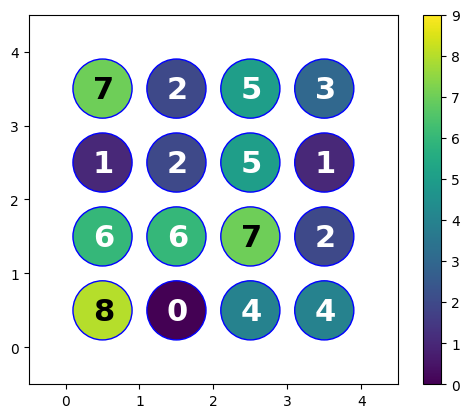

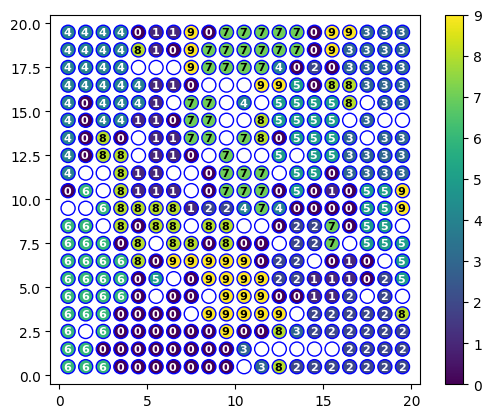

In [ ]:
#
#   4X4
#
Vwmap_4X4 = {}
for x in train_data:
    w = som_4X4.winner(x)
    Vwmap_4X4[w] = 1

fig = plt.figure()
ax = fig.add_subplot(111, aspect='equal')
all_patches = []
cmap = cm.get_cmap('viridis')
for i in range(4):
    for j in range(4):
        rect_color = cmap(int((256*Neuron_lable_4X4[j][i])/9))
        text_color = 'white' if rect_color[0] < 0.4 else 'black' # Flip the color for better visibility
        if (i, j) in Vwmap_4X4:
            ax.add_patch( patches.Circle((i+0.5, j+0.5), 0.4, linewidth=1, fill=1, edgecolor='b' , facecolor=rect_color,))
            plt. text(i+0.37,  j+0.3725,  str(Neuron_lable_4X4[j][i]), color=text_color, fontdict={'weight': 'bold',  'size': 22})
        else:
            ax.add_patch( patches.Circle((i+0.5, j+0.5), 0.4, linewidth=1, fill=1, edgecolor='b' , facecolor='white'))

sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=0, vmax=9))
plt.colorbar(sm, ax=ax)
plt.axis([-0.5, som_4X4.get_weights().shape[0]+0.5, -0.5,  som_4X4.get_weights().shape[1]+0.5])
plt.savefig('outputs/figures/SOM_4X4_Neurons_label.png')
plt.show()
#print(Neuron_lable_4X4)



#
#   20X20
#
Vwmap_20X20 = {}
for x in train_data:
    w = som_20X20.winner(x)
    Vwmap_20X20[w] = 1

fig = plt.figure()
ax = fig.add_subplot(111, aspect='equal')
all_patches = []
cmap = cm.get_cmap('viridis')
for i in range(20):
    for j in range(20):
        rect_color = cmap(int((256*Neuron_lable_20X20[j][i])/9))
        text_color = 'white' if rect_color[0] < 0.4 else 'black' # Flip the color for better visibility
        if (i, j) in Vwmap_20X20:
            ax.add_patch( patches.Circle((i+0.5, j+0.5), 0.4, linewidth=1, fill=1, edgecolor='b' , facecolor=rect_color,))
            plt. text(i+0.225,  j+0.325,  str(Neuron_lable_20X20[j][i]), color=text_color, fontdict={'weight': 'bold',  'size': 8})
        else:
            ax.add_patch( patches.Circle((i+0.5, j+0.5), 0.4, linewidth=1, fill=1, edgecolor='b' , facecolor='white'))

sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=0, vmax=9))
plt.colorbar(sm, ax=ax)
plt.axis([-0.5, som_20X20.get_weights().shape[0]+0.5, -0.5,  som_20X20.get_weights().shape[1]+0.5])
plt.savefig('outputs/figures/SOM_20X20_Neurons_label.png')
plt.show()
#print(Neuron_lable_20X20)


# Task 3: Classification with Single Layer Feedforward Network (SLFN)

**Importing Data Set**

In [ ]:
raw_data = pd.read_csv('data/titanic.csv')
df = raw_data

**Preparing The Data Set**

Histogram of Passenger's Age:


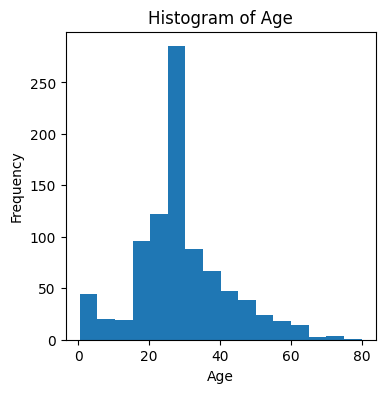

Since the histogram is asymmetric, the best way to fill the 'nan' data is the median of the data


In [ ]:
print("Histogram of Passenger\'s Age:")
plt.figure(figsize=(4, 4))
plt.hist(df['Age'].dropna(),16)  # Dropna to remove missing values
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.title('Histogram of Age')
plt.savefig('outputs/figures/Histogram_Ages.png')
plt.show()
print('Since the histogram is asymmetric, the best way to fill the \'nan\' data is the median of the data')


In [ ]:
#fill the "NaN" data of "Age" column with median of the data
df['Age'].fillna(df['Age'].median(), inplace=True)


#Add a new column named "Deck" to remove the "Cabin" column so the handeling
#   of missing data would be easier
df['Deck'] = df["Cabin"].astype(str).str[0]


#replacing alphabetical value with the numerical value
df['Sex'].replace(['male','female'],[1,-1],inplace=True)    #replacing Male with 1 and female with -1
df['Embarked'].replace(['S','C','Q'],[-1,0,1],inplace=True)  #replacing S, and C, Q with -1, 0, and 1
df['Embarked'].fillna(df['Embarked'].dropna().median(), inplace=True)
df['Deck'].replace(['A','B','C','D','E','F','G','T','n'],[0,1,2,3,4,5,6,7,-1],inplace=True)
df['has_Deck'] = (df['Deck'] >= 0).astype(float)

#demoving "Cabin" column
df.drop(["Cabin"], axis=1, inplace=True)

#making ID, Label, and Data set
All_ID = df['PassengerId']
All_label = np.transpose([df['Survived']])      #binarry representation of the output
All_data = np.transpose([df['Pclass'], df['Sex'], df['Age'], df['SibSp'], df['Parch'], df['Fare'], df['Deck'], df['has_Deck'], df['Embarked']])

#print("ID: ", All_ID.shape)
#print("Data: ", All_data.shape)
#print("Label: ", All_label.shape)

#normalizing Data set:
All_data[:,5] = np.log10( 1 + All_data[:,5])
All_mean = np.mean(All_data, axis=0)
All_std = np.std(All_data, axis=0)
All_data[:,0] = (All_data[:,0] - All_mean[0])/All_std[0]  #Pclass
All_data[:,1] = (All_data[:,1] - All_mean[1])/All_std[1]  #Sex
All_data[:,2] = (All_data[:,2] - All_mean[2])/All_std[2]  #Age
All_data[:,3] = (All_data[:,3] - All_mean[3])/All_std[3]  #SibSp
All_data[:,4] = (All_data[:,4] - All_mean[4])/All_std[4]  #Parch
All_data[:,5] = (All_data[:,5] - All_mean[5])/All_std[5]  #Fare
All_data[:,6] = (All_data[:,6] - All_mean[6])/All_std[6]  #Deck
All_data[:,7] = (All_data[:,7] - All_mean[7])/All_std[7]  #has_Deck
All_data[:,8] = (All_data[:,8] - All_mean[8])/All_std[8]  #Embarked


#shuffeling Data
combined_data = list(zip(All_ID, All_label, All_data))
random.shuffle(combined_data)
shuffled_ID, shuffled_label, shuffled_data = zip(*combined_data)


#split the data set into train set and test set, with train/test ratio of 80%
split_point = int(0.8 * len(shuffled_label))

train_ID    = np.array(shuffled_ID[:split_point]).T
train_label = np.array(shuffled_label[:split_point]).T
train_data  = np.array(shuffled_data[:split_point]).T

test_ID    = np.array(shuffled_ID[split_point:]).T
test_label = np.array(shuffled_label[split_point:]).T
test_data  = np.array(shuffled_data[split_point:]).T


**Implement SLFN from scratch**

Initialization

In [ ]:
# parameters
num_inp_neuron = train_data.shape[0]
num_hid_neuron = 30
num_out_neuron = train_label.shape[0]
num_epoch = 2000
learning_rate_online = 1e-2
learning_rate_offline = 1e-2


# Randomly Initializing Weights and Biases
Wh_off = np.random.normal(loc=0, scale=1, size=(num_hid_neuron, num_inp_neuron+1))
Wo_off = np.random.normal(loc=0, scale=1, size=(num_out_neuron, num_hid_neuron+1))

Wh_on = np.copy(Wh_off)    #np.random.normal(loc=0, scale=1, size=(num_hid_neuron, num_inp_neuron+1))
Wo_on = np.copy(Wo_off)    #np.random.normal(loc=0, scale=1, size=(num_out_neuron, num_hid_neuron+1))


Implementing Necessary Functions

In [ ]:
def check_dim (X):
    if X.ndim == 1:
        return np.expand_dims(X, axis=1)
    else:
        return X


def ReLU(Z):
    return np.maximum(0, Z)


def Sigmoid(Z):
    return 1/(1+np.exp(-Z))


def FeedForward(X, Wh, Wo):
    X  = check_dim(X)
    # Adding a row of 1s to represent the bias as an input
    B1 = np.ones((X.shape[1], 1))               #bias row
    D1 = np.concatenate((B1, X.T), axis=1).T    #input feature  data of layer 1
    R1 = np.dot(Wh, D1)                         #raw data of neurons of layer 1
    Z1 = ReLU(R1)                               #output   of neurons of layer 1
    Z1 = check_dim(Z1)                          #check the dimension of data

    # Adding a row of 1s to represent the bias as an input
    B2 = np.ones((Z1.shape[1], 1))              #bias row
    D2 = np.concatenate((B2, Z1.T), axis=1).T   #input feature  data of layer 2
    R2 = np.dot(Wo, D2)                         #raw data of neurons of layer 2
    Z2 = Sigmoid(R2)                            #output   of neurons of layer 2
    Z2 = check_dim(Z2)                          #check the dimension of data
    return D1, R1, Z1, D2, R2, Z2


def Cross_Entropy_loss(true_label, prid_label):
    epsilon = 1e-10
    prid_label_clipped = np.clip(prid_label, epsilon, 1 - epsilon)
    loss = (true_label * np.log(prid_label_clipped)) + ((1-true_label) * np.log(1-prid_label_clipped))
    return -np.mean(loss)


def Error_function(true_label, prid_label):
    Error = true_label - prid_label
    return (0.5 * np.dot(Error, Error.T))


def Gradient_of_Sigmoid (prid_label):
    return prid_label * (1-prid_label)


def Gradient_of_ReLU (prid_label):
    return (prid_label > 0).astype(float)


def Gradient_of_Cross_Entropy_loss (true_label, prid_label):
    return (true_label/prid_label) - ((1-true_label)/(1-prid_label))


def Gradient_of_Error_function (true_label, prid_label):
    return prid_label - true_label


def BackPropagation (data, true_label, D1, R1, Z1, D2, R2, Z2, Wh, Wo, learning_rate, Err_Gradient_func = Gradient_of_Error_function):
    prid_label = Z2
    # Delta Wo
    delta_o = Err_Gradient_func(true_label, prid_label) * Gradient_of_Sigmoid(Z2)
    Delta_Wo = learning_rate * np.dot(delta_o, D2.T)
    # Delta Wh
    delta_h = np.dot(Wo[:,1:].T, delta_o) * Gradient_of_ReLU(Z1)
    Delta_Wh = learning_rate * np.dot(delta_h, D1.T)
    # update weights
    Wo = Wo - Delta_Wo
    Wh = Wh - Delta_Wh
    return Wh, Wo


def put_char(cnt, ch):
    str = ""
    for i in range(int(cnt)):
        str += ch
    return str


**Training**

Offline Training

In [ ]:
off_error = np.zeros((num_epoch,))
off_loss  = np.zeros((num_epoch,))

_, _, _, _, _, Z2 = FeedForward(train_data, Wh_off, Wo_off)
print("Initial Error: ", Error_function(train_label, Z2).item())
print("Initial Loss:  ", Cross_Entropy_loss(train_label, Z2))
print("")

print("Training Progress:     0 % [                                                    ]", end="")
#   Offline Trainning
for i in range(num_epoch):
    cnt = 100*i/num_epoch/2
    if cnt > 0 and cnt%1 == 0:
        print(put_char(59+np.log10(2*cnt), '\b'), int(2*cnt), "%", '[', put_char(cnt, '#'), put_char(50-cnt, ' '), '\b]', end="")
    #   feed forward
    D1, R1, Z1, D2, R2, Z2 = FeedForward(train_data, Wh_off, Wo_off)
    #   calculating Error
    off_error[i] = Error_function(train_label, Z2)
    off_loss[i]  = Cross_Entropy_loss(train_label, Z2)

    #   back propagation
    Wh_off, Wo_off = BackPropagation(train_data, train_label, D1, R1, Z1, D2, R2, Z2, Wh_off, Wo_off, learning_rate_offline)
cnt = 50;
_, _, _, _, _, label_probability_train_off = FeedForward(train_data, Wh_off, Wo_off)
predict_train_label_off = (label_probability_train_off >= 0.5).astype(int)
print(put_char(59+np.log10(2*cnt), '\b'), int(2*cnt), "%", '[', put_char(cnt, '#'), put_char(50-cnt, ' '), '\b]')
print("Done!")
print("")

print("Error: ", Error_function(train_label, label_probability_train_off).item())
print("Loss:  ", Cross_Entropy_loss(train_label, label_probability_train_off))
print("")


#   Creating the Confusion Matrix
conf_matrix_train_off = np.zeros((2,2), dtype=int);
for i in range(train_label.shape[1]):
    conf_matrix_train_off[train_label[0,i]][predict_train_label_off[0,i]] += 1;

print("Confusion Maxrix of offline Training on training data is: ")
print(conf_matrix_train_off)
print("")

#   Calculating Accuracy, Recall, Precision, and F1-score of train data set
TN_train_off = conf_matrix_train_off[0][0]
FP_train_off = conf_matrix_train_off[0][1]
FN_train_off = conf_matrix_train_off[1][0]
TP_train_off = conf_matrix_train_off[1][1]

Accuracy_train_off  = (TP_train_off+TN_train_off)/(TP_train_off+TN_train_off+FP_train_off+FN_train_off)
Precision_train_off = TP_train_off/(TP_train_off+FP_train_off)
Recall_train_off    = TP_train_off/(TP_train_off+FN_train_off)
F1_score_train_off  = 2*Precision_train_off*Recall_train_off/(Precision_train_off+Recall_train_off)

print("Accuracy  of offline mode on trainig data is: ", f"{Accuracy_train_off*100:.4f}%")
print("Precision of offline mode on trainig data is: ", f"{Precision_train_off:.4f}")
print("Recall    of offline mode on trainig data is: ", f"{Recall_train_off:.4f}")
print("F1-score  of offline mode on trainig data is: ", f"{F1_score_train_off:.4f}")

print("\r\n\r\n\r\n\r\n\r\n\r\n")

Initial Error:  237.04663218637842
Initial Loss:   nan

Training Progress:     0 % [                                                    ] 2 % [ #                                                   ] 4 % [ ##                                                  ] 6 % [ ###                                                 ] 8 % [ ####                                                ] 10 % [ #####                                               ] 12 % [ ######                                              ] 14 % [ #######                                             ]

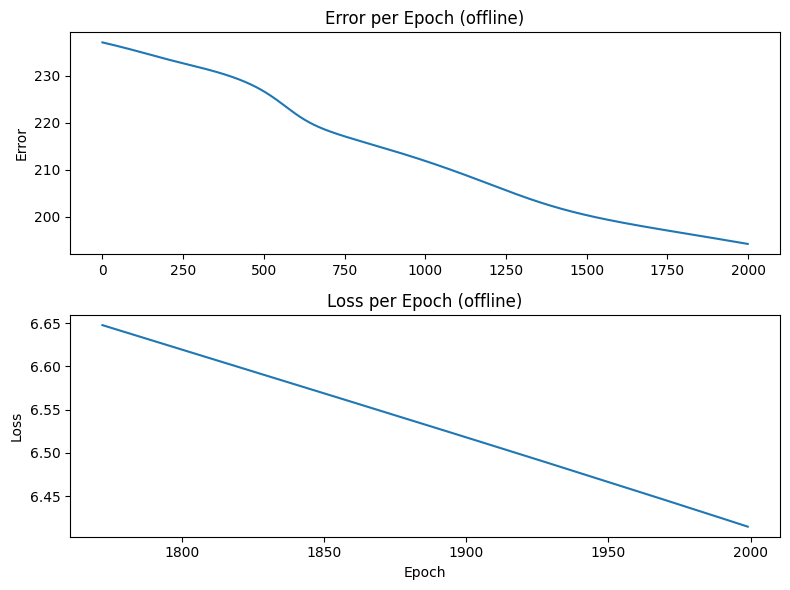

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(8, 6))

axes[0].plot(off_error)
axes[0].set_title('Error per Epoch (offline)')
axes[0].set_ylabel('Error')

axes[1].plot(off_loss)
axes[1].set_title('Loss per Epoch (offline)')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')

plt.tight_layout()
plt.savefig('outputs/figures/Offline_Training_Error_Loss.png')
plt.show()


Online Training

In [ ]:
on_error = np.zeros((num_epoch,))
on_loss  = np.zeros((num_epoch,))

_, _, _, _, _, Z2 = FeedForward(train_data, Wh_on, Wo_on)
print("Initial Error: ", Error_function(train_label, Z2).item())
print("Initial Loss:  ", Cross_Entropy_loss(train_label, Z2))
print("")

te = np.zeros((train_label.shape[1],))
tl = np.zeros((train_label.shape[1],))

print("Training Progress:     0 % [                                                    ]", end="")
#   Online Trainning
for i in range(num_epoch):
    cnt = 100*i/num_epoch/2
    if cnt > 0 and cnt%1 == 0:
        print(put_char(59+np.log10(2*cnt), '\b'), int(2*cnt), "%", '[', put_char(cnt, '#'), put_char(50-cnt, ' '), '\b]', end="")
    for s in range(train_label.shape[1]):
        #   feed forward
        D1, R1, Z1, D2, R2, Z2 = FeedForward(train_data[:,s], Wh_on, Wo_on)
        #   back propagation
        Wh_on, Wo_on = BackPropagation(train_data[:,s], train_label[:,s], D1, R1, Z1, D2, R2, Z2, Wh_on, Wo_on, learning_rate_online)

    #   calculating Error
    D1, R1, Z1, D2, R2, Z2 = FeedForward(train_data, Wh_on, Wo_on)
    on_error[i] = Error_function(train_label, Z2)
    on_loss[i]  = Cross_Entropy_loss(train_label, Z2)

cnt = 50;
_, _, _, _, _, label_probability_train_on = FeedForward(train_data, Wh_on, Wo_on)
predict_train_label_on = (label_probability_train_on >= 0.5).astype(int)
print(put_char(59+np.log10(2*cnt), '\b'), int(2*cnt), "%", '[', put_char(cnt, '#'), put_char(50-cnt, ' '), '\b]')
print("Done!")
print("")

print("Error: ", Error_function(train_label, label_probability_train_on).item())
print("Loss:  ", Cross_Entropy_loss(train_label, label_probability_train_on))
print("")


#   Creating the Confusion Matrix
conf_matrix_train_on = np.zeros((2,2), dtype=int);
for i in range(train_label.shape[1]):
    conf_matrix_train_on[train_label[0,i]][predict_train_label_on[0,i]] += 1;

print("Confusion Maxrix of online Training on training data is: ")
print(conf_matrix_train_on)
print("")

#   Calculating Accuracy, Recall, Precision, and F1-score of train data set
TN_train_on = conf_matrix_train_on[0][0]
FP_train_on = conf_matrix_train_on[0][1]
FN_train_on = conf_matrix_train_on[1][0]
TP_train_on = conf_matrix_train_on[1][1]

Accuracy_train_on  = (TP_train_on+TN_train_on)/(TP_train_on+TN_train_on+FP_train_on+FN_train_on)
Precision_train_on = TP_train_on/(TP_train_on+FP_train_on)
Recall_train_on    = TP_train_on/(TP_train_on+FN_train_on)
F1_score_train_on  = 2*Precision_train_on*Recall_train_on/(Precision_train_on+Recall_train_on)

print("Accuracy  of online mode on trainig data is: ", f"{Accuracy_train_on*100:.4f}%")
print("Precision of online mode on trainig data is: ", f"{Precision_train_on:.4f}")
print("Recall    of online mode on trainig data is: ", f"{Recall_train_on:.4f}")
print("F1-score  of online mode on trainig data is: ", f"{F1_score_train_on:.4f}")

Initial Error:  237.04663218637842
Initial Loss:   nan

Training Progress:     0 % [                                                    ] 2 % [ #                                                   ] 4 % [ ##                                                  ] 6 % [ ###                                                 ] 8 % [ ####                                                ] 10 % [ #####                                               ] 12 % [ ######                                              ] 14 % [ #######                                             ]

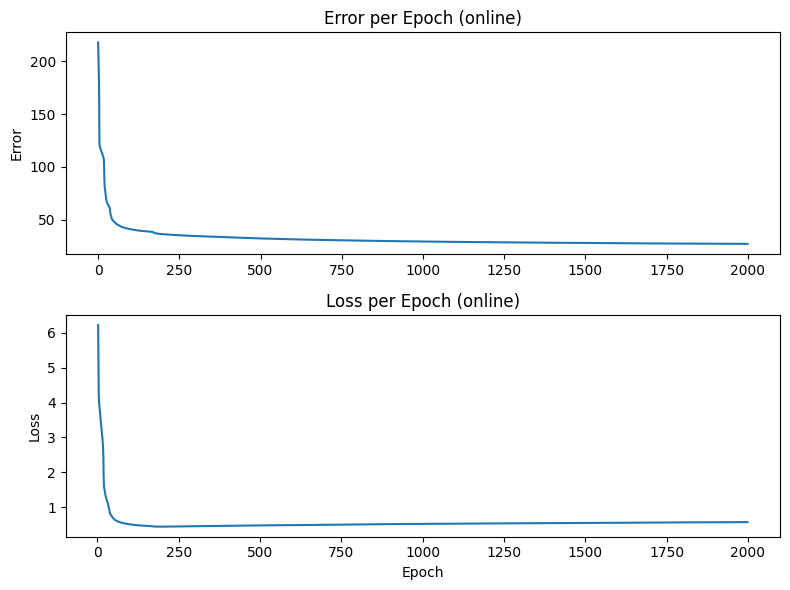

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(8, 6))

axes[0].plot(on_error)
axes[0].set_title('Error per Epoch (online)')
axes[0].set_ylabel('Error')

axes[1].plot(on_loss)
axes[1].set_title('Loss per Epoch (online)')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')

plt.tight_layout()
plt.savefig('outputs/figures/Online_Training_Error_Loss.png')
plt.show()


**Evaluating Models**

In [ ]:
#
#   Offline Training Results
#
_, _, _, _, _, label_probability_off = FeedForward(test_data, Wh_off, Wo_off)
predict_test_label_off = (label_probability_off >= 0.5).astype(int)

#   Creating the Confusion Matrix
conf_matrix_off = np.zeros((2,2), dtype=int);
for i in range(test_label.shape[1]):
    conf_matrix_off[test_label[0,i]][predict_test_label_off[0,i]] += 1;

print("Confusion Maxrix of offline Training is: ")
print(conf_matrix_off)
print("")

#   Calculating Accuracy, Recall, Precision, and F1-score
TN_off = conf_matrix_off[0][0]
FP_off = conf_matrix_off[0][1]
FN_off = conf_matrix_off[1][0]
TP_off = conf_matrix_off[1][1]

Accuracy_off  = (TP_off+TN_off)/(TP_off+TN_off+FP_off+FN_off)
Precision_off = TP_off/(TP_off+FP_off)
Recall_off    = TP_off/(TP_off+FN_off)
F1_score_off  = 2*Precision_off*Recall_off/(Precision_off+Recall_off)

print("Accuracy  of offline mode is: ", f"{Accuracy_off*100:.4f}%")
print("Precision of offline mode is: ", f"{Precision_off:.4f}")
print("Recall    of offline mode is: ", f"{Recall_off:.4f}")
print("F1-score  of offline mode is: ", f"{F1_score_off:.4f}")

#   Calculating AUC-ROC curve
TPR_off = np.zeros((101,), dtype=float)
FPR_off = np.zeros((101,), dtype=float)
for i in range(101):
    pl_tmp = (label_probability_off >= i/100).astype(int)
    TP_tmp = np.sum(test_label     * pl_tmp)
    FN_tmp = np.sum(test_label     * (1-pl_tmp))
    FP_tmp = np.sum((1-test_label) * pl_tmp)
    TN_tmp = np.sum((1-test_label) * (1-pl_tmp))
    TPR_off[i] = TP_tmp/(TP_tmp+FN_tmp)
    FPR_off[i] = FP_tmp/(FP_tmp+TN_tmp)

TPR_off = np.nan_to_num(TPR_off, nan=0)
FPR_off = np.nan_to_num(FPR_off, nan=0)
#   Sorting the ROC points by FPR
sorted_indices = np.argsort(FPR_off)
TPR_off = TPR_off[sorted_indices]
FPR_off = FPR_off[sorted_indices]

#   Calculating AUC using the trapezoidal rule
AUC_off = np.trapz(TPR_off, FPR_off)
print("AUC-ROC   of offline mode is: ", f"{AUC_off:.4f}")
print("")
print("")
print("")


#
#   Online Training Results
#
_, _, _, _, _, label_probability_on = FeedForward(test_data, Wh_on,  Wo_on)
predict_test_label_on  = (label_probability_on >= 0.5).astype(int)

#   Creating the Confusion Matrix
conf_matrix_on = np.zeros((2,2), dtype=int);
for i in range(test_label.shape[1]):
    conf_matrix_on [test_label[0,i]][predict_test_label_on [0,i]] += 1;

print("Confusion Maxrix of online Training is: ")
print(conf_matrix_on)
print("")

#   Calculating Accuracy, Recall, Precision, and F1-score
TN_on  = conf_matrix_on[0][0]
FP_on  = conf_matrix_on[0][1]
FN_on  = conf_matrix_on[1][0]
TP_on  = conf_matrix_on[1][1]

Accuracy_on   = (TP_on+TN_on)/(TP_on+TN_on+FP_on+FN_on)
Precision_on  = TP_on/(TP_on+FP_on)
Recall_on     = TP_on/(TP_on+FN_on)
F1_score_on   = 2*Precision_on*Recall_on/(Precision_on+Recall_on)

print("Accuracy  of online  mode is: ", f"{Accuracy_on*100:.4f}%")
print("Precision of online  mode is: ", f"{Precision_on:.4f}")
print("Recall    of online  mode is: ", f"{Recall_on:.4f}")
print("F1-score  of online  mode is: ", f"{F1_score_on:.4f}")

#   Calculating AUC-ROC curve
TPR_on = np.zeros((101,), dtype=float)
FPR_on = np.zeros((101,), dtype=float)
for i in range(101):
    pl_tmp = (label_probability_on >= i/100).astype(int)
    TP_tmp = np.sum(test_label     * pl_tmp)
    FN_tmp = np.sum(test_label     * (1-pl_tmp))
    FP_tmp = np.sum((1-test_label) * pl_tmp)
    TN_tmp = np.sum((1-test_label) * (1-pl_tmp))
    TPR_on[i] = TP_tmp/(TP_tmp+FN_tmp)
    FPR_on[i] = FP_tmp/(FP_tmp+TN_tmp)

TPR_on = np.nan_to_num(TPR_on, nan=0)
FPR_on = np.nan_to_num(FPR_on, nan=0)
#   Sorting the ROC points by FPR
sorted_indices = np.argsort(FPR_on)
TPR_on = TPR_on[sorted_indices]
FPR_on = FPR_on[sorted_indices]

#   Calculating AUC using the trapezoidal rule
AUC_on = np.trapz(TPR_on, FPR_on)
print("AUC-ROC   of online  mode is: ", f"{AUC_on:.4f}")


Confusion Maxrix of offline Training is: 
[[69 49]
 [40 21]]

Accuracy  of offline mode is:  50.2793%
Precision of offline mode is:  0.3000
Recall    of offline mode is:  0.3443
F1-score  of offline mode is:  0.3206
AUC-ROC   of offline mode is:  0.4116



Confusion Maxrix of online Training is: 
[[99 19]
 [18 43]]

Accuracy  of online  mode is:  79.3296%
Precision of online  mode is:  0.6935
Recall    of online  mode is:  0.7049
F1-score  of online  mode is:  0.6992
AUC-ROC   of online  mode is:  0.8255


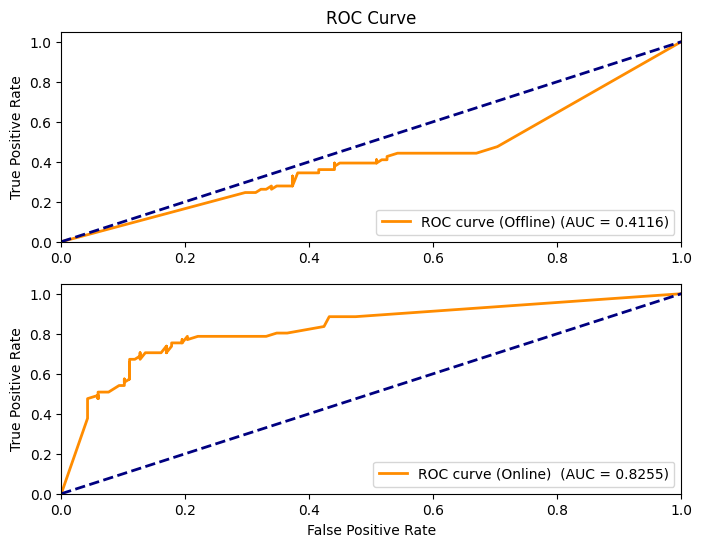

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(8, 6))

axes[0].plot(FPR_off, TPR_off, color='darkorange', lw=2, label='ROC curve (Offline) (AUC = %0.4f)' % AUC_off)
axes[0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')  # Random guessing line
axes[0].set_xlim([0.0, 1.0])
axes[0].set_ylim([0.0, 1.05])
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve')
axes[0].legend(loc="lower right")

axes[1].plot(FPR_on, TPR_on, color='darkorange', lw=2, label='ROC curve (Online)  (AUC = %0.4f)' % AUC_on)
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')  # Random guessing line
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend(loc="lower right")

plt.savefig('outputs/figures/ROC_AUC_figure.png')
plt.show()


# Visualizing Implementation Approach

In [13]:
# Load the data from the pickle file
#with open(save_path, 'rb') as f:
#    data = pickle.load(f)

with open('outputs/results.pkl', 'rb') as f:
    data = pickle.load(f)

data_run                = data['run']
data_train_error_off    = data['train_error_off']		    /	(data_run+1)
data_train_loss_off     = data['train_loss_off']			/	(data_run+1)
data_train_Accuracy_off = data['train_Accuracy_off']		/	(data_run+1)
data_train_Precision_off= data['train_Precision_off']	    /	(data_run+1)
data_train_Recall_off   = data['train_Recall_off']		    /	(data_run+1)
data_test_error_off     = data['test_off_error']			/	(data_run+1)
data_test_loss_off      = data['test_off_loss']			    /	(data_run+1)
data_test_Accuracy_off  = data['test_Accuracy_off']		    /	(data_run+1)
data_test_Precision_off = data['test_Precision_off']		/	(data_run+1)
data_test_Recall_off    = data['test_Recall_off']		    /	(data_run+1)
data_AUC_off            = data['AUC_off']				    /	(data_run+1)
data_train_error_on     = data['train_error_on']			/	(data_run+1)
data_train_loss_on      = data['train_loss_on']			    /	(data_run+1)
data_train_Accuracy_on  = data['train_Accuracy_on']		    /	(data_run+1)
data_train_Precision_on = data['train_Precision_on']		/	(data_run+1)
data_train_Recall_on    = data['train_Recall_on']		    /	(data_run+1)
data_test_error_on      = data['test_on_error']			    /	(data_run+1)
data_test_loss_on       = data['test_on_loss']			    /	(data_run+1)
data_test_Accuracy_on   = data['test_Accuracy_on']		    /	(data_run+1)
data_test_Precision_on  = data['test_Precision_on']		    /	(data_run+1)
data_test_Recall_on     = data['test_Recall_on']			/	(data_run+1)
data_AUC_on             = data['AUC_on']					/	(data_run+1)


data_train_F1_score_off  = 2*data_train_Precision_off * data_train_Recall_off / (data_train_Precision_off + data_train_Recall_off)
data_test_F1_score_off   = 2* data_test_Precision_off *  data_test_Recall_off / ( data_test_Precision_off +  data_test_Recall_off)
data_train_F1_score_on   = 2*data_train_Precision_on  * data_train_Recall_on  / (data_train_Precision_on  + data_train_Recall_on )
data_test_F1_score_on    = 2* data_test_Precision_on  *  data_test_Recall_on  / ( data_test_Precision_on  +  data_test_Recall_on )


x = np.arange(data_train_error_off.shape[1])*100  # 21 values
y = np.arange(data_train_error_off.shape[0])*5  # 10 values
X, Y = np.meshgrid(x, y)


**Visualizing**

Offline Training Mode

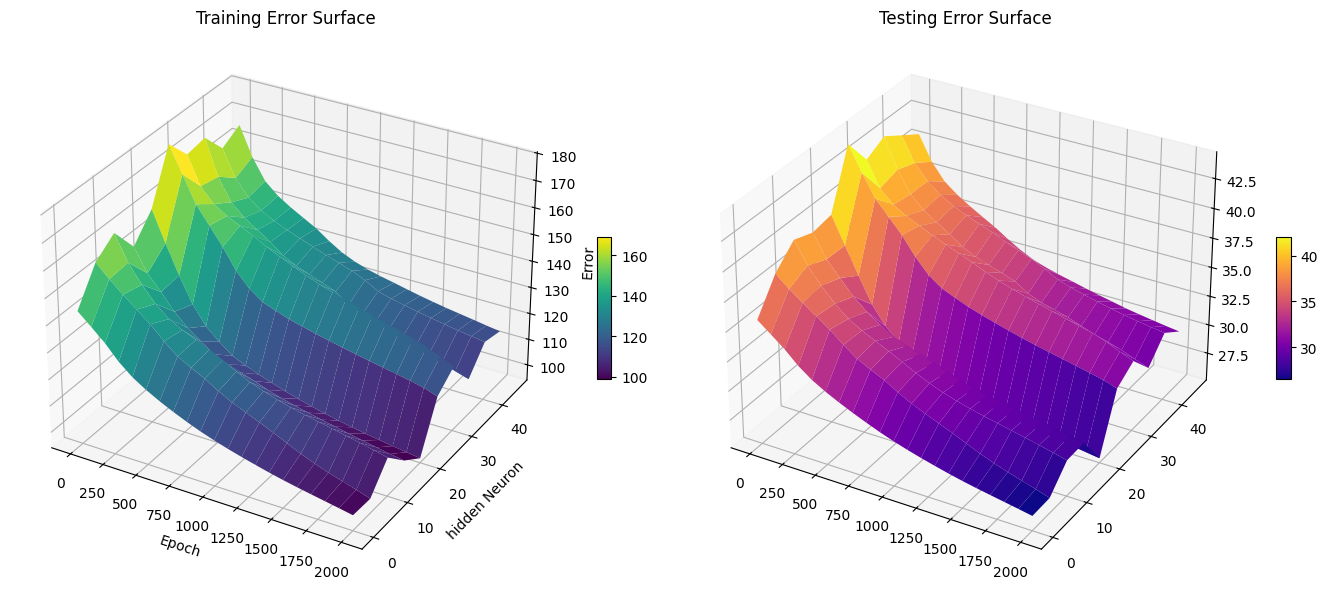

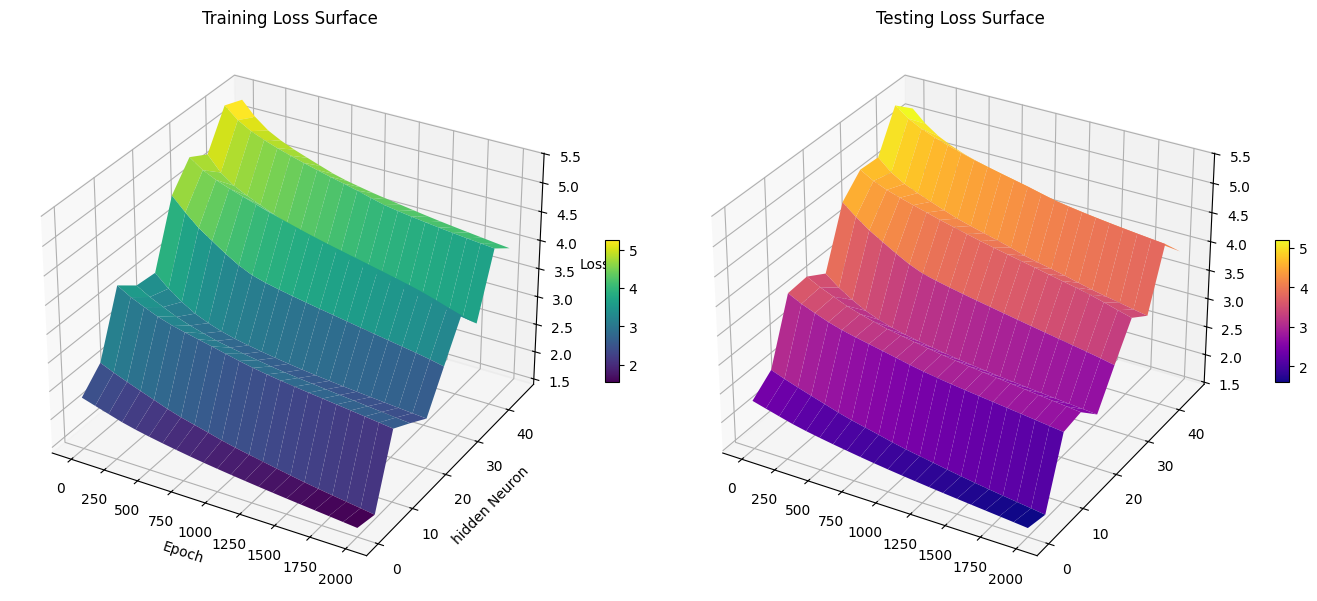

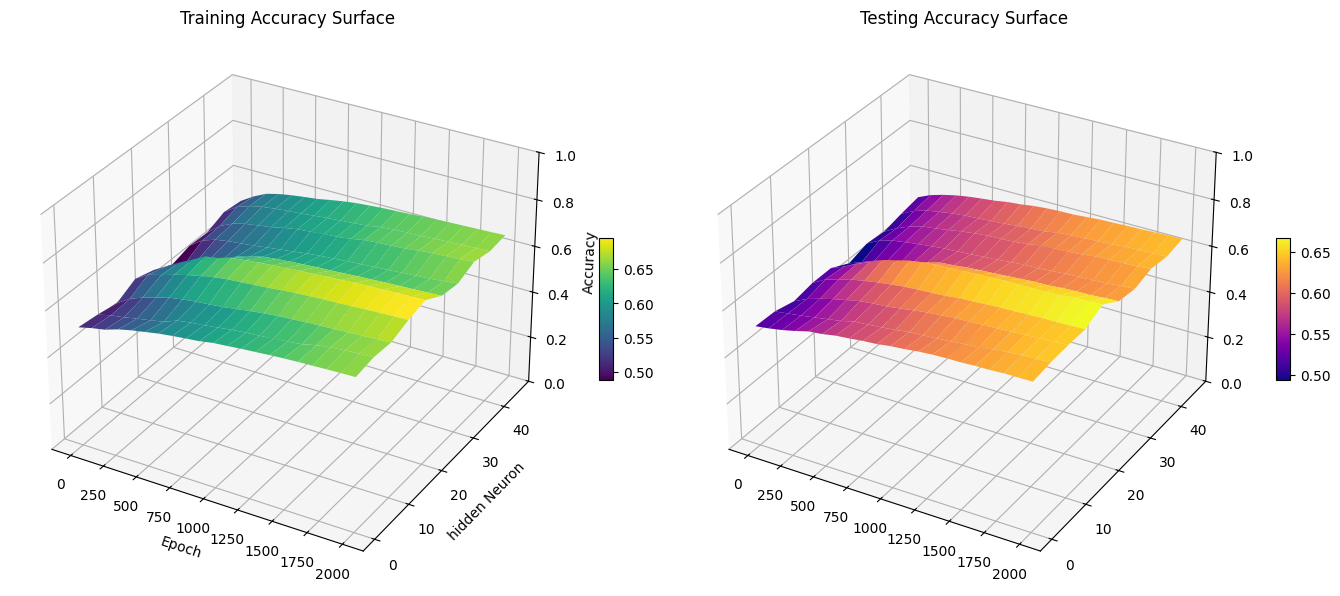

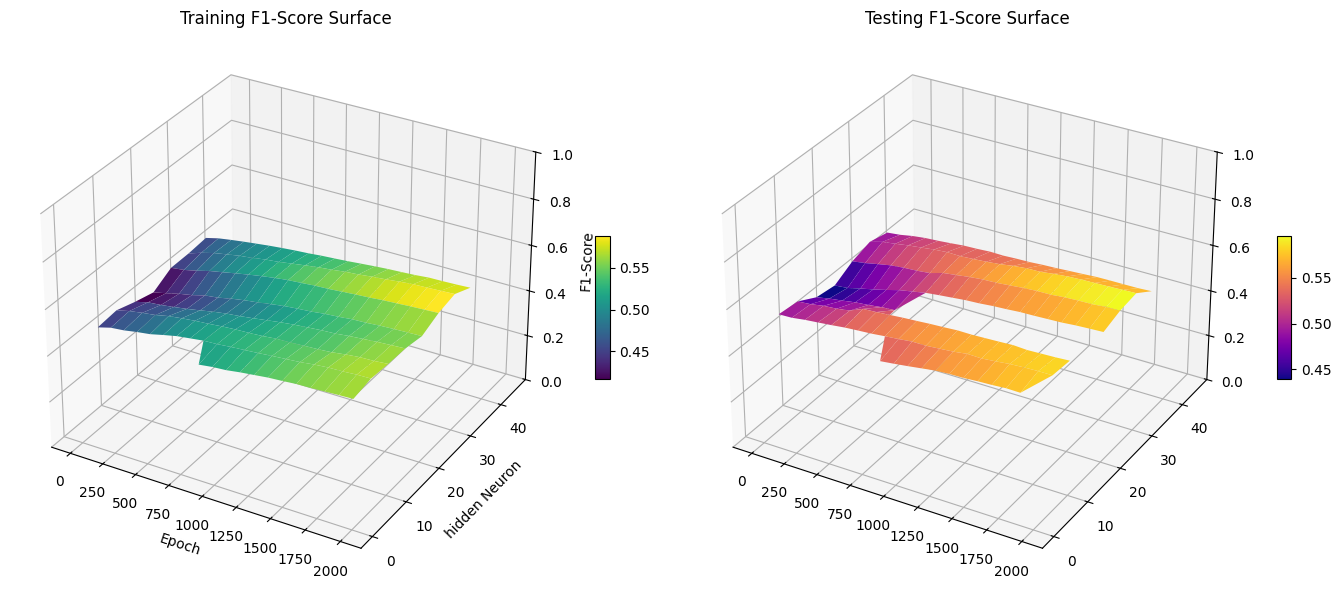

In [ ]:
#######################################
#   Training Error & Testing Error
#######################################
fig = plt.figure(figsize=(14, 6))
# Subplot 1: Training Error
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
surf1 = ax1.plot_surface(X, Y, data_train_error_off, cmap='viridis')
ax1.set_title("Training Error Surface")
ax1.set_xlabel('Epoch')
ax1.set_ylabel('hidden Neuron')
ax1.set_zlabel('Error')
fig.colorbar(surf1, ax=ax1, shrink=0.25, aspect=10)
# Subplot 2: Testing Error
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
surf2 = ax2.plot_surface(X, Y, data_test_error_off, cmap='plasma')
ax2.set_title("Testing Error Surface")
fig.colorbar(surf2, ax=ax2, shrink=0.25, aspect=10)

plt.tight_layout()
plt.savefig('outputs/figures/Offline_Train_Test_Error_surface.png')
plt.show()
print("\r\n\r\n")



#######################################
#   Training Loss & Testing Loss
#######################################
fig = plt.figure(figsize=(14, 6))
# Subplot 1: Training Error
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
surf1 = ax1.plot_surface(X, Y, data_train_loss_off, cmap='viridis')
ax1.set_title("Training Loss Surface")
ax1.set_xlabel('Epoch')
ax1.set_ylabel('hidden Neuron')
ax1.set_zlabel('Loss')
fig.colorbar(surf1, ax=ax1, shrink=0.25, aspect=10)
# Subplot 2: Testing Error
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
surf2 = ax2.plot_surface(X, Y, data_test_loss_off, cmap='plasma')
ax2.set_title("Testing Loss Surface")
fig.colorbar(surf2, ax=ax2, shrink=0.25, aspect=10)

plt.tight_layout()
plt.savefig('outputs/figures/Offline_Train_Test_Loss_surface.png')
plt.show()
print("\r\n\r\n")


#######################################
#   Training Accuracy & Testing Accuracy
#######################################
fig = plt.figure(figsize=(14, 6))
# Subplot 1: Training Accuracy
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
surf1 = ax1.plot_surface(X, Y, data_train_Accuracy_off, cmap='viridis')
ax1.set_title("Training Accuracy Surface")
ax1.set_xlabel('Epoch')
ax1.set_ylabel('hidden Neuron')
ax1.set_zlabel('Accuracy')
ax1.set_zlim(0, 1)
fig.colorbar(surf1, ax=ax1, shrink=0.25, aspect=10)
# Subplot 2: Testing Accuracy
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
surf2 = ax2.plot_surface(X, Y, data_test_Accuracy_off, cmap='plasma')
ax2.set_title("Testing Accuracy Surface")
fig.colorbar(surf2, ax=ax2, shrink=0.25, aspect=10)
ax2.set_zlim(0, 1)

plt.tight_layout()
plt.savefig('outputs/figures/Offline_Train_Test_Accuracy_surface.png')
plt.show()
print("\r\n\r\n")


#######################################
#   Training F1 & Testing F1
#######################################
fig = plt.figure(figsize=(14, 6))
# Subplot 1: Training F1-Score
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
surf1 = ax1.plot_surface(X, Y, data_train_F1_score_off, cmap='viridis')
ax1.set_title("Training F1-Score Surface")
ax1.set_xlabel('Epoch')
ax1.set_ylabel('hidden Neuron')
ax1.set_zlabel('F1-Score')
ax1.set_zlim(0, 1)
fig.colorbar(surf1, ax=ax1, shrink=0.25, aspect=10)
# Subplot 2: Testing F1-Score
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
surf2 = ax2.plot_surface(X, Y, data_test_F1_score_off, cmap='plasma')
ax2.set_title("Testing F1-Score Surface")
fig.colorbar(surf2, ax=ax2, shrink=0.25, aspect=10)
ax2.set_zlim(0, 1)

plt.tight_layout()
plt.savefig('outputs/figures/Offline_Train_Test_F1_Score_surface.png')
plt.show()
print("\r\n\r\n")


Online Training Mode

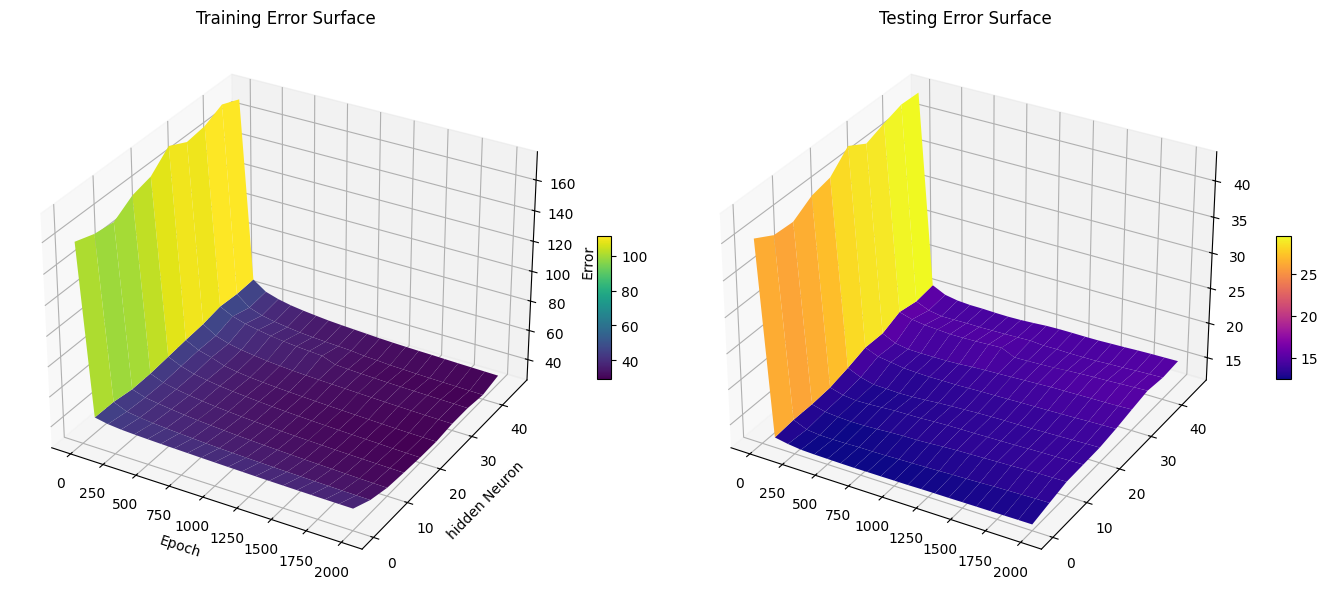

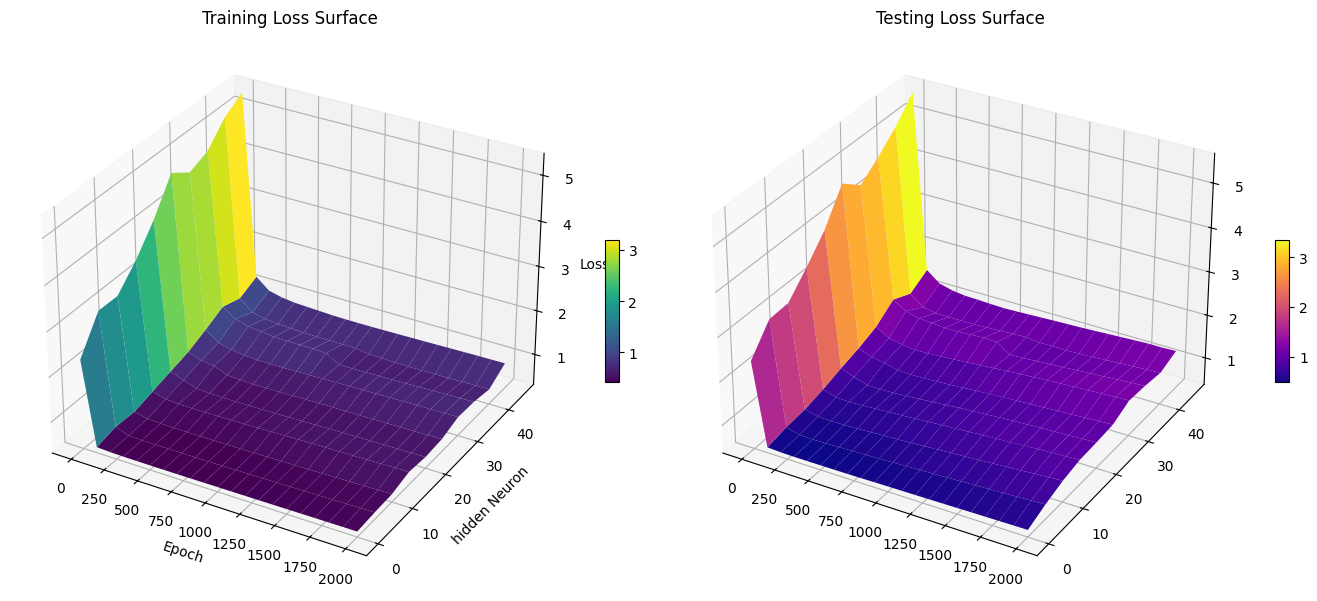

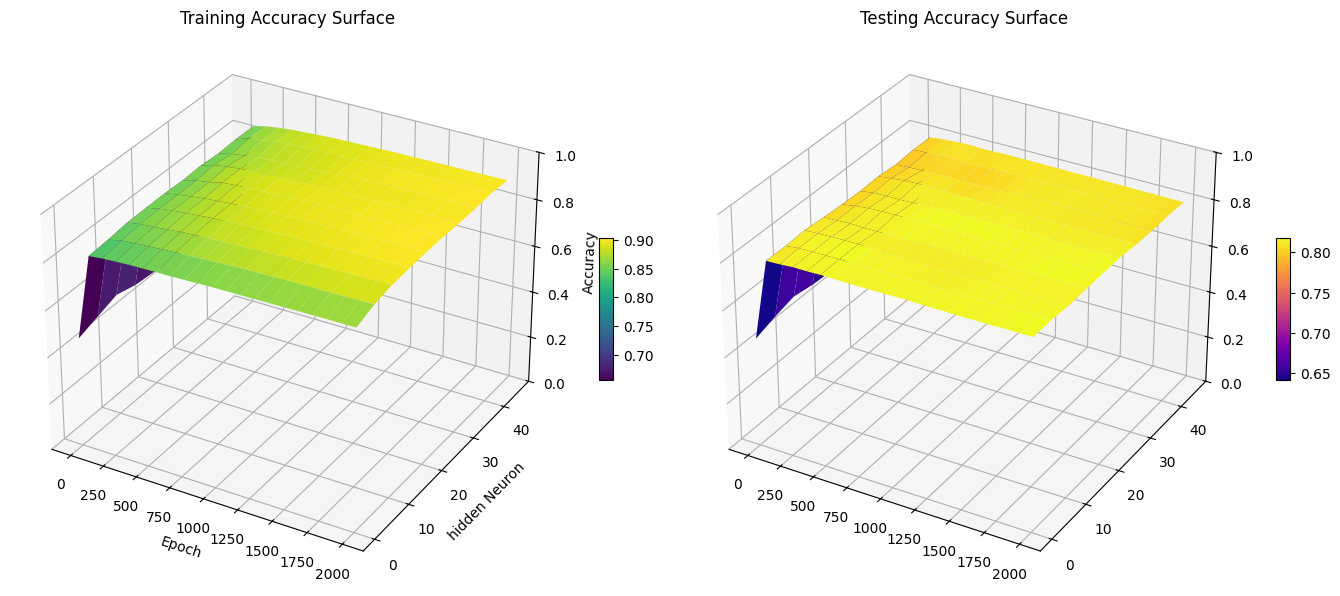

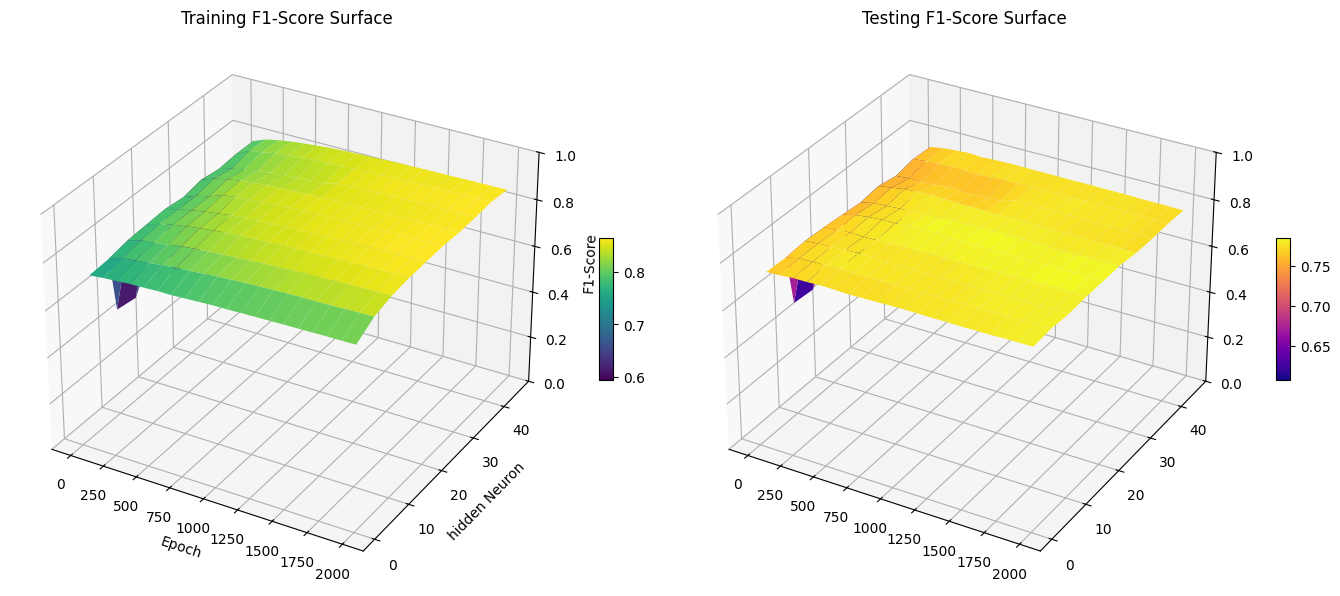

In [15]:
#######################################
#   Training Error & Testing Error
#######################################
fig = plt.figure(figsize=(14, 6))
# Subplot 1: Training Error
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
surf1 = ax1.plot_surface(X, Y, data_train_error_on, cmap='viridis')
ax1.set_title("Training Error Surface")
ax1.set_xlabel('Epoch')
ax1.set_ylabel('hidden Neuron')
ax1.set_zlabel('Error')
fig.colorbar(surf1, ax=ax1, shrink=0.25, aspect=10)
# Subplot 2: Testing Error
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
surf2 = ax2.plot_surface(X, Y, data_test_error_on, cmap='plasma')
ax2.set_title("Testing Error Surface")
fig.colorbar(surf2, ax=ax2, shrink=0.25, aspect=10)

plt.tight_layout()
plt.savefig('outputs/figures/online_Train_Test_Error_surface.png')
plt.show()
print("\r\n\r\n")



#######################################
#   Training Loss & Testing Loss
#######################################
fig = plt.figure(figsize=(14, 6))
# Subplot 1: Training Error
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
surf1 = ax1.plot_surface(X, Y, data_train_loss_on, cmap='viridis')
ax1.set_title("Training Loss Surface")
ax1.set_xlabel('Epoch')
ax1.set_ylabel('hidden Neuron')
ax1.set_zlabel('Loss')
fig.colorbar(surf1, ax=ax1, shrink=0.25, aspect=10)
# Subplot 2: Testing Error
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
surf2 = ax2.plot_surface(X, Y, data_test_loss_on, cmap='plasma')
ax2.set_title("Testing Loss Surface")
fig.colorbar(surf2, ax=ax2, shrink=0.25, aspect=10)

plt.tight_layout()
plt.savefig('outputs/figures/online_Train_Test_Loss_surface.png')
plt.show()
print("\r\n\r\n")


#######################################
#   Training Accuracy & Testing Accuracy
#######################################
fig = plt.figure(figsize=(14, 6))
# Subplot 1: Training Accuracy
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
surf1 = ax1.plot_surface(X, Y, data_train_Accuracy_on, cmap='viridis')
ax1.set_title("Training Accuracy Surface")
ax1.set_xlabel('Epoch')
ax1.set_ylabel('hidden Neuron')
ax1.set_zlabel('Accuracy')
ax1.set_zlim(0, 1)
fig.colorbar(surf1, ax=ax1, shrink=0.25, aspect=10)
# Subplot 2: Testing Accuracy
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
surf2 = ax2.plot_surface(X, Y, data_test_Accuracy_on, cmap='plasma')
ax2.set_title("Testing Accuracy Surface")
fig.colorbar(surf2, ax=ax2, shrink=0.25, aspect=10)
ax2.set_zlim(0, 1)

plt.tight_layout()
plt.savefig('outputs/figures/online_Train_Test_Accuracy_surface.png')
plt.show()
print("\r\n\r\n")


#######################################
#   Training F1 & Testing F1
#######################################
fig = plt.figure(figsize=(14, 6))
# Subplot 1: Training F1-Score
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
surf1 = ax1.plot_surface(X, Y, data_train_F1_score_on, cmap='viridis')
ax1.set_title("Training F1-Score Surface")
ax1.set_xlabel('Epoch')
ax1.set_ylabel('hidden Neuron')
ax1.set_zlabel('F1-Score')
ax1.set_zlim(0, 1)
fig.colorbar(surf1, ax=ax1, shrink=0.25, aspect=10)
# Subplot 2: Testing F1-Score
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
surf2 = ax2.plot_surface(X, Y, data_test_F1_score_on, cmap='plasma')
ax2.set_title("Testing F1-Score Surface")
fig.colorbar(surf2, ax=ax2, shrink=0.25, aspect=10)
ax2.set_zlim(0, 1)

plt.tight_layout()
plt.savefig('outputs/figures/online_Train_Test_F1_Score_surface.png')
plt.show()
print("\r\n\r\n")



# Choosing Implementation Approach (do not run it)

In [ ]:
save_path = 'outputs/results.pkl'

runs = 25;
NS = [5, 10, 15, 20, 25, 30, 35, 40, 45, 50]


num_inp_neuron = train_data.shape[0]
num_out_neuron = train_label.shape[0]
num_epoch = 2000
learning_rate_online = 1e-2
learning_rate_offline = 1e-2


train_error_off     = np.zeros((len(NS), int(num_epoch/100)+1,))
train_loss_off      = np.zeros((len(NS), int(num_epoch/100)+1,))
train_Accuracy_off  = np.zeros((len(NS), int(num_epoch/100)+1,))
train_Precision_off = np.zeros((len(NS), int(num_epoch/100)+1,))
train_Recall_off    = np.zeros((len(NS), int(num_epoch/100)+1,))
train_F1_score_off  = np.zeros((len(NS), int(num_epoch/100)+1,))
test_off_error      = np.zeros((len(NS), int(num_epoch/100)+1,))
test_off_loss       = np.zeros((len(NS), int(num_epoch/100)+1,))
test_Accuracy_off   = np.zeros((len(NS), int(num_epoch/100)+1,))
test_Precision_off  = np.zeros((len(NS), int(num_epoch/100)+1,))
test_Recall_off     = np.zeros((len(NS), int(num_epoch/100)+1,))
test_F1_score_off   = np.zeros((len(NS), int(num_epoch/100)+1,))
AUC_off             = np.zeros((len(NS), int(num_epoch/100)+1,))


train_error_on     = np.zeros((len(NS), int(num_epoch/100)+1,))
train_loss_on      = np.zeros((len(NS), int(num_epoch/100)+1,))
train_Accuracy_on  = np.zeros((len(NS), int(num_epoch/100)+1,))
train_Precision_on = np.zeros((len(NS), int(num_epoch/100)+1,))
train_Recall_on    = np.zeros((len(NS), int(num_epoch/100)+1,))
train_F1_score_on  = np.zeros((len(NS), int(num_epoch/100)+1,))
test_on_error      = np.zeros((len(NS), int(num_epoch/100)+1,))
test_on_loss       = np.zeros((len(NS), int(num_epoch/100)+1,))
test_Accuracy_on   = np.zeros((len(NS), int(num_epoch/100)+1,))
test_Precision_on  = np.zeros((len(NS), int(num_epoch/100)+1,))
test_Recall_on     = np.zeros((len(NS), int(num_epoch/100)+1,))
test_F1_score_on   = np.zeros((len(NS), int(num_epoch/100)+1,))
AUC_on             = np.zeros((len(NS), int(num_epoch/100)+1,))


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
def save_results_on_drive(path):

    results = {
        'run'                 : run                ,
        'train_error_off'     : train_error_off    ,
        'train_loss_off'      : train_loss_off     ,
        'train_Accuracy_off'  : train_Accuracy_off ,
        'train_Precision_off' : train_Precision_off,
        'train_Recall_off'    : train_Recall_off   ,
        'train_F1_score_off'  : train_F1_score_off ,
        'test_off_error'      : test_off_error     ,
        'test_off_loss'       : test_off_loss      ,
        'test_Accuracy_off'   : test_Accuracy_off  ,
        'test_Precision_off'  : test_Precision_off ,
        'test_Recall_off'     : test_Recall_off    ,
        'test_F1_score_off'   : test_F1_score_off  ,
        'AUC_off'             : AUC_off            ,
        'train_error_on'      : train_error_on     ,
        'train_loss_on'       : train_loss_on      ,
        'train_Accuracy_on'   : train_Accuracy_on  ,
        'train_Precision_on'  : train_Precision_on ,
        'train_Recall_on'     : train_Recall_on    ,
        'train_F1_score_on'   : train_F1_score_on  ,
        'test_on_error'       : test_on_error      ,
        'test_on_loss'        : test_on_loss       ,
        'test_Accuracy_on'    : test_Accuracy_on   ,
        'test_Precision_on'   : test_Precision_on  ,
        'test_Recall_on'      : test_Recall_on     ,
        'test_F1_score_on'    : test_F1_score_on   ,
        'AUC_on'              : AUC_on             ,
    }

    with open(path, 'wb') as f:
        pickle.dump(results, f)

    print(f"Variables saved to {path}")

In [ ]:
for run in range(runs):
    print("\r\n\r\nRun: ", run+1, ",\tHC= ", end="")
    for hnc in range(len(NS)):
        print(NS[hnc], ", ", end="")

        #############################
        #       initial Value       #
        #############################
        num_hid_neuron = NS[hnc]


        # Randomly Initializing Weights and Biases
        Wh_off = np.random.normal(loc=0, scale=1, size=(num_hid_neuron, num_inp_neuron+1))
        Wo_off = np.random.normal(loc=0, scale=1, size=(num_out_neuron, num_hid_neuron+1))

        Wh_on = np.copy(Wh_off)    #np.random.normal(loc=0, scale=1, size=(num_hid_neuron, num_inp_neuron+1))
        Wo_on = np.copy(Wo_off)    #np.random.normal(loc=0, scale=1, size=(num_out_neuron, num_hid_neuron+1))


        #   Offline Trainning
        cntr = 0;
        for i in range(num_epoch+1):
            if i % 100 == 0:

                #   Train
                #       calculating Errors
                _, _, _, _, _, label_probability_train_off = FeedForward(train_data, Wh_off, Wo_off)
                train_error_off[hnc, cntr] += Error_function(train_label, label_probability_train_off)
                train_loss_off[hnc, cntr]  += Cross_Entropy_loss(train_label, label_probability_train_off)

                #       Creating the Confusion Matrix
                predict_train_label_off = (label_probability_train_off >= 0.5).astype(int)
                conf_matrix_train_off = np.zeros((2,2), dtype=int);
                for j in range(train_label.shape[1]):
                    conf_matrix_train_off[train_label[0,j]][predict_train_label_off[0,j]] += 1;

                #       Calculating Accuracy, Recall, Precision, and F1-score of train data set
                TN_train_off = conf_matrix_train_off[0][0]
                FP_train_off = conf_matrix_train_off[0][1]
                FN_train_off = conf_matrix_train_off[1][0]
                TP_train_off = conf_matrix_train_off[1][1]

                #       Calculating Scores
                train_Accuracy_off[hnc, cntr]  += (TP_train_off+TN_train_off)/(TP_train_off+TN_train_off+FP_train_off+FN_train_off)
                train_Precision_off[hnc, cntr] += TP_train_off/(TP_train_off+FP_train_off)
                train_Recall_off[hnc, cntr]    += TP_train_off/(TP_train_off+FN_train_off)



                #   Test
                _, _, _, _, _, label_probability_off = FeedForward(test_data, Wh_off, Wo_off)
                test_off_error[hnc, cntr] += Error_function(test_label, label_probability_off)
                test_off_loss[hnc, cntr]  += Cross_Entropy_loss(test_label, label_probability_off)

                #       Creating the Confusion Matrix
                predict_test_label_off = (label_probability_off >= 0.5).astype(int)
                conf_matrix_off = np.zeros((2,2), dtype=int);
                for j in range(test_label.shape[1]):
                    conf_matrix_off[test_label[0,j]][predict_test_label_off[0,j]] += 1;

                #       Calculating Accuracy, Recall, Precision, and F1-score
                TN_off = conf_matrix_off[0][0]
                FP_off = conf_matrix_off[0][1]
                FN_off = conf_matrix_off[1][0]
                TP_off = conf_matrix_off[1][1]

                test_Accuracy_off[hnc, cntr]  += (TP_off+TN_off)/(TP_off+TN_off+FP_off+FN_off)
                test_Precision_off[hnc, cntr] += TP_off/(TP_off+FP_off)
                test_Recall_off[hnc, cntr]    += TP_off/(TP_off+FN_off)



                #   Calculating AUC-ROC curve
                TPR_off = np.zeros((51,), dtype=float)
                FPR_off = np.zeros((51,), dtype=float)
                for j in range(50):
                    pl_tmp = (label_probability_off >= j/50).astype(int)
                    TP_tmp = np.sum(test_label     * pl_tmp)
                    FN_tmp = np.sum(test_label     * (1-pl_tmp))
                    FP_tmp = np.sum((1-test_label) * pl_tmp)
                    TN_tmp = np.sum((1-test_label) * (1-pl_tmp))
                    TPR_off[j] = TP_tmp/(TP_tmp+FN_tmp)
                    FPR_off[j] = FP_tmp/(FP_tmp+TN_tmp)

                TPR_off = np.nan_to_num(TPR_off, nan=0)
                FPR_off = np.nan_to_num(FPR_off, nan=0)
                #   Sorting the ROC points by FPR
                sorted_indices = np.argsort(FPR_off)
                TPR_off = TPR_off[sorted_indices]
                FPR_off = FPR_off[sorted_indices]

                #   Calculating AUC using the trapezoidal rule
                AUC_off[hnc, cntr] += np.trapz(TPR_off, FPR_off)
                cntr += 1;


            #   feed forward
            D1, R1, Z1, D2, R2, Z2 = FeedForward(train_data, Wh_off, Wo_off)
            #   calculating Error


            #   back propagation
            Wh_off, Wo_off = BackPropagation(train_data, train_label, D1, R1, Z1, D2, R2, Z2, Wh_off, Wo_off, learning_rate_offline)
    save_results_on_drive(save_path)




Run:  1 ,	HC= 5 , 10 , 15 , 20 , 25 , 30 , 35 , 40 , 45 , 50 , Variables saved to /content/drive/MyDrive/results.pkl


Run:  2 ,	HC= 5 , 10 , 15 , 20 , 25 , 30 , 35 , 40 , 45 , 50 , Variables saved to /content/drive/MyDrive/results.pkl


Run:  3 ,	HC= 5 , 10 , 15 , 20 , 25 , 30 , 35 , 40 , 45 , 50 , Variables saved to /content/drive/MyDrive/results.pkl


Run:  4 ,	HC= 5 , 10 , 15 , 20 , 25 , 30 , 35 , 40 , 45 , 50 , Variables saved to /content/drive/MyDrive/results.pkl


Run:  5 ,	HC= 5 , 10 , 15 , 20 , 25 , 30 , 35 , 40 , 45 , 50 , Variables saved to /content/drive/MyDrive/results.pkl


Run:  6 ,	HC= 5 , 10 , 15 , 20 , 25 , 30 , 35 , 40 , 45 , 50 , Variables saved to /content/drive/MyDrive/results.pkl


Run:  7 ,	HC= 5 , 10 , 15 , 20 , 25 , 30 , 35 , 40 , 45 , 50 , Variables saved to /content/drive/MyDrive/results.pkl


Run:  8 ,	HC= 5 , 10 , 15 , 20 , 25 , 30 , 35 , 40 , 45 , 50 , Variables saved to /content/drive/MyDrive/results.pkl


Run:  9 ,	HC= 5 , 10 , 15 , 20 , 25 , 30 , 35 

In [ ]:
for run in range(runs):
    print("\r\n\r\nRun: ", run+1, ",\tHC= ", end="")
    for hnc in range(len(NS)):
        print(NS[hnc], ", ", end="")

        #############################
        #       initial Value       #
        #############################
        num_hid_neuron = NS[hnc]


        # Randomly Initializing Weights and Biases
        Wh_on = np.random.normal(loc=0, scale=1, size=(num_hid_neuron, num_inp_neuron+1))
        Wo_on = np.random.normal(loc=0, scale=1, size=(num_out_neuron, num_hid_neuron+1))

        Wh_on = np.copy(Wh_on)    #np.random.normal(loc=0, scale=1, size=(num_hid_neuron, num_inp_neuron+1))
        Wo_on = np.copy(Wo_on)    #np.random.normal(loc=0, scale=1, size=(num_out_neuron, num_hid_neuron+1))


        #   online Trainning
        cntr = 0;
        for i in range(num_epoch+1):
            if i % 100 == 0:

                #   Train
                #       calculating Errors
                _, _, _, _, _, label_probability_train_on = FeedForward(train_data, Wh_on, Wo_on)
                train_error_on [hnc, cntr]  += Error_function(train_label, label_probability_train_on)
                train_loss_on  [hnc, cntr]  += Cross_Entropy_loss(train_label, label_probability_train_on)

                #       Creating the Confusion Matrix
                predict_train_label_on = (label_probability_train_on >= 0.5).astype(int)
                conf_matrix_train_on = np.zeros((2,2), dtype=int);
                for j in range(train_label.shape[1]):
                    conf_matrix_train_on[train_label[0,j]][predict_train_label_on[0,j]] += 1;

                #       Calculating Accuracy, Recall, Precision, and F1-score of train data set
                TN_train_on = conf_matrix_train_on[0][0]
                FP_train_on = conf_matrix_train_on[0][1]
                FN_train_on = conf_matrix_train_on[1][0]
                TP_train_on = conf_matrix_train_on[1][1]

                #       Calculating Scores
                train_Accuracy_on[hnc, cntr]  += (TP_train_on+TN_train_on)/(TP_train_on+TN_train_on+FP_train_on+FN_train_on)
                train_Precision_on[hnc, cntr] += TP_train_on/(TP_train_on+FP_train_on)
                train_Recall_on[hnc, cntr]    += TP_train_on/(TP_train_on+FN_train_on)



                #   Test
                _, _, _, _, _, label_probability_on = FeedForward(test_data, Wh_on, Wo_on)
                test_on_error[hnc, cntr] += Error_function(test_label, label_probability_on)
                test_on_loss[hnc, cntr]  += Cross_Entropy_loss(test_label, label_probability_on)

                #       Creating the Confusion Matrix
                predict_test_label_on = (label_probability_on >= 0.5).astype(int)
                conf_matrix_on = np.zeros((2,2), dtype=int);
                for j in range(test_label.shape[1]):
                    conf_matrix_on[test_label[0,j]][predict_test_label_on[0,j]] += 1;

                #       Calculating Accuracy, Recall, Precision, and F1-score
                TN_on = conf_matrix_on[0][0]
                FP_on = conf_matrix_on[0][1]
                FN_on = conf_matrix_on[1][0]
                TP_on = conf_matrix_on[1][1]

                test_Accuracy_on[hnc, cntr]  += (TP_on+TN_on)/(TP_on+TN_on+FP_on+FN_on)
                test_Precision_on[hnc, cntr] += TP_on/(TP_on+FP_on)
                test_Recall_on[hnc, cntr]    += TP_on/(TP_on+FN_on)



                #   Calculating AUC-ROC curve
                TPR_on = np.zeros((51,), dtype=float)
                FPR_on = np.zeros((51,), dtype=float)
                for j in range(50):
                    pl_tmp = (label_probability_on >= j/50).astype(int)
                    TP_tmp = np.sum(test_label     * pl_tmp)
                    FN_tmp = np.sum(test_label     * (1-pl_tmp))
                    FP_tmp = np.sum((1-test_label) * pl_tmp)
                    TN_tmp = np.sum((1-test_label) * (1-pl_tmp))
                    TPR_on[j] = TP_tmp/(TP_tmp+FN_tmp)
                    FPR_on[j] = FP_tmp/(FP_tmp+TN_tmp)

                TPR_on = np.nan_to_num(TPR_on, nan=0)
                FPR_on = np.nan_to_num(FPR_on, nan=0)
                #   Sorting the ROC points by FPR
                sorted_indices = np.argsort(FPR_on)
                TPR_on = TPR_on[sorted_indices]
                FPR_on = FPR_on[sorted_indices]

                #   Calculating AUC using the trapezoidal rule
                AUC_on[hnc, cntr] += np.trapz(TPR_on, FPR_on)
                cntr += 1;

            for s in range(train_label.shape[1]):
                #   feed forward
                D1, R1, Z1, D2, R2, Z2 = FeedForward(train_data[:,s], Wh_on, Wo_on)
                #   back propagation
                Wh_on, Wo_on = BackPropagation(train_data[:,s], train_label[:,s], D1, R1, Z1, D2, R2, Z2, Wh_on, Wo_on, learning_rate_online)
    save_results_on_drive(save_path)




Run:  1 ,	HC= 5 , 10 , 15 , 20 , 25 , 30 , 35 , 40 , 45 , 50 , Variables saved to /content/drive/MyDrive/results.pkl


Run:  2 ,	HC= 5 , 10 , 15 , 20 , 25 , 30 , 35 , 40 , 45 , 50 , Variables saved to /content/drive/MyDrive/results.pkl


Run:  3 ,	HC= 5 , 10 , 15 , 20 , 25 , 30 , 35 , 40 , 45 , 50 , Variables saved to /content/drive/MyDrive/results.pkl


Run:  4 ,	HC= 5 , 10 , 15 , 20 , 25 , 30 , 35 , 40 , 45 , 50 , Variables saved to /content/drive/MyDrive/results.pkl


Run:  5 ,	HC= 5 , 10 , 15 , 20 , 25 , 30 , 35 , 40 , 45 , 50 , Variables saved to /content/drive/MyDrive/results.pkl


Run:  6 ,	HC= 5 , 10 , 15 , 20 , 25 , 30 , 35 , 40 , 45 , 50 , Variables saved to /content/drive/MyDrive/results.pkl


Run:  7 ,	HC= 5 , 10 , 15 , 20 , 25 , 30 , 35 , 40 , 45 , 50 , Variables saved to /content/drive/MyDrive/results.pkl


Run:  8 ,	HC= 5 , 10 , 15 , 20 , 25 , 30 , 35 , 40 , 45 , 50 , Variables saved to /content/drive/MyDrive/results.pkl


Run:  9 ,	HC= 5 , 10 , 15 , 20 , 25 , 30 , 35 